# AirSense Cameroon — Exploratory Data Analysis

**Hackathon:** IndabaX Cameroon 2026  
**Theme:** *L'IA au service de la résilience climatique et sanitaire au Cameroun*  
**Author:** AirSense Team

---

This EDA answers two mission questions before any modelling begins:

1. **What does the target look like?** — distributions, skewness, WHO exceedance rates
2. **What drives it?** — which climate factors correlate with PM2.5, and how they vary by region and season

Each section ends with a decision that feeds directly into the modelling notebook.

---

## Table of Contents
1. [Setup & Data Load](#s1)
2. [Dataset Overview](#s2)
3. [Target Distributions](#s3)
4. [Biomass Burning Proxy (NH3)](#s3b)
5. [Pollution by Region](#s4)
6. [Seasonality & Harmattan Effect](#s5)
7. [Harmattan Deep Dive](#s5b)
8. [Weather–Pollution Correlations](#s6)
9. [Weather Code Analysis](#s6b)
10. [Compound Interactions](#s7)
11. [City-Level Rankings](#s8)
12. [Year-over-Year Trend](#s8b)
13. [Proxy vs Real Data Validation](#s9)
14. [CAMS-only Correlation Validation](#s9b)
15. [New v2 Features](#s10)
16. [BLH & VPD Deep Dive](#s10b)
17. [Full Feature Correlation Ranking](#s11)
18. [EDA Summary & Modelling Decisions](#s12)


<a id='s1'></a>
## Section 1 — Setup and Load

Data arrives fully cleaned from the cleaning notebook (`airsense_eda_ready.parquet`): 87,240 rows, 0 nulls, real CAMS air quality values merged with Open-Meteo weather for 40 cities across all 10 regions of Cameroon.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings, os
warnings.filterwarnings('ignore')

NAVY='#0D1B3E'; TEAL='#0F7B8A'; AMBER='#F59E0B'
GREEN='#22C55E'; RED='#EF4444'; ORANGE='#F97316'; PURPLE='#8B5CF6'
REGION_COLORS = {
    'Far North':RED,'North':ORANGE,'Adamawa':AMBER,'West':PURPLE,
    'North West':'#EC4899','Littoral':TEAL,'Centre':'#06B6D4',
    'East':'#84CC16','South West':GREEN,'South':'#10B981',
}
plt.rcParams.update({
    'figure.facecolor':'white','axes.facecolor':'white',
    'axes.spines.top':False,'axes.spines.right':False,
    'axes.grid':True,'grid.alpha':0.3,'grid.color':'#CBD5E1',
    'font.family':'sans-serif','axes.titlesize':13,'axes.labelsize':11,
})
data_dir    = os.path.abspath(os.path.join(os.getcwd(),'..','data'))
outputs_dir = os.path.abspath(os.path.join(data_dir,'..','outputs'))
os.makedirs(outputs_dir, exist_ok=True)

df = pd.read_csv(os.path.join(data_dir,'cameroon_final.csv'), parse_dates=['date'])
print(f'Dataset: {df.shape[0]:,} rows x {df.shape[1]} columns')
print(f'Dates  : {df["date"].min().date()} to {df["date"].max().date()}')
print(f'Nulls  : {df.isnull().sum().sum()}')
v2_cols = ['wind_gust','boundary_layer_height','vpd','aq_source']
for col in v2_cols:
    print(f'  {col:<25} {"✓ present" if col in df.columns else "✗ MISSING — re-run cleaning v2"}')

Dataset: 87,240 rows x 80 columns
Dates  : 2020-01-01 to 2025-12-20
Nulls  : 0
  wind_gust                 ✓ present
  boundary_layer_height     ✓ present
  vpd                       ✓ present
  aq_source                 ✓ present


In [2]:
# ── Full null audit and cleanup ───────────────────────────────────────────────
total_rows = len(df)

null_summary = pd.DataFrame({
    'nulls': df.isnull().sum(),
    'pct':   (df.isnull().sum() / total_rows * 100).round(2),
    'dtype': df.dtypes,
}).sort_values('nulls', ascending=False)

null_summary = null_summary[null_summary['nulls'] > 0]

print(f'Shape  : {df.shape[0]:,} rows x {df.shape[1]} columns')
print(f'Columns with nulls: {len(null_summary)} / {df.shape[1]}\n')
print(null_summary.to_string())

# ── Categorise ────────────────────────────────────────────────────────────────
fully_null  = null_summary[null_summary['pct'] == 100].index.tolist()
mostly_null = null_summary[null_summary['pct'] >  50].index.tolist()
partial     = null_summary[(null_summary['pct'] > 0) & 
                           (null_summary['pct'] <= 50)].index.tolist()

print(f'\n── 100% null (drop immediately) ────────────────')
print(fully_null if fully_null else 'none')

print(f'\n── >50% null (investigate before dropping) ─────')
print(mostly_null if mostly_null else 'none')

print(f'\n── <50% null (impute) ───────────────────────────')
print(partial if partial else 'none')

# ── Drop fully null columns ───────────────────────────────────────────────────
if fully_null:

# NOTE: sample_weight, eu_aqi, and blh_mean fixes are applied in
# the cleaning v2 script, so these columns should already be gone.
    print(f'\nDropping {len(fully_null)} fully null columns...')
    df.drop(columns=fully_null, inplace=True)

Shape  : 87,240 rows x 80 columns
Columns with nulls: 0 / 80

Empty DataFrame
Columns: [nulls, pct, dtype]
Index: []

── 100% null (drop immediately) ────────────────
none

── >50% null (investigate before dropping) ─────
none

── <50% null (impute) ───────────────────────────
none


**Load confirmed:** 87,240 rows × 80 columns, 0 nulls, all key v2 features present (`wind_gust`, `boundary_layer_height`, `vpd`, `aq_source`). Data is ready for analysis.


<a id='s2'></a>
## Section 2 — Dataset Overview

Confirming compound coverage, WHO exceedance rates, and data provenance split before any analysis.


In [3]:
targets    = ['pm25_target','pm10_target','dust_target','co_target','no2_target','o3_target','so2_target','aod_target']
who_limits = {'pm25_target':15,'pm10_target':45,'o3_target':100,'no2_target':25,'so2_target':40,'co_target':4000}

print(f"{'Compound':<18} {'Min':>8} {'Mean':>8} {'Median':>8} {'Max':>8}  {'WHO':>8}  {'%>WHO':>8}")
print('-'*78)
for col in targets:
    lim = who_limits.get(col)
    exc = f"{(df[col]>lim).mean()*100:.1f}%" if lim else 'n/a'
    print(f"  {col:<16} {df[col].min():>8.2f} {df[col].mean():>8.2f} {df[col].median():>8.2f} {df[col].max():>8.2f}  {str(lim) if lim else 'none':>8}  {exc:>8}")

if 'aq_source' in df.columns:
    cams_n = (df['aq_source']=='CAMS').sum(); proxy_n = (df['aq_source']=='proxy').sum()
    print(f'\nProvenance — CAMS real: {cams_n:,} ({cams_n/len(df)*100:.1f}%)  Proxy: {proxy_n:,} ({proxy_n/len(df)*100:.1f}%)')

Compound                Min     Mean   Median      Max       WHO     %>WHO
------------------------------------------------------------------------------
  pm25_target          0.50    18.86    15.47   335.17        15     51.9%
  pm10_target          0.72    34.82    24.43   670.93        45     24.9%
  dust_target          0.00    31.47    10.71   600.00      none       n/a
  co_target           59.21   276.56   256.00  2261.33      4000      0.0%
  no2_target           0.00     1.92     1.57    31.06        25      0.0%
  o3_target           10.62    52.01    47.17   160.71       100      1.1%
  so2_target           0.00     0.53     0.42    10.69        40      0.0%
  aod_target           0.03     0.25     0.19     1.86      none       n/a

Provenance — CAMS real: 49,400 (56.6%)  Proxy: 37,840 (43.4%)


### Dataset Summary

| Compound | Mean | Median | Max | %>WHO |
|----------|------|--------|-----|-------|
| **PM2.5** | 18.86 μg/m³ | 15.47 | 335.2 | **51.9%** |
| PM10 | 34.82 μg/m³ | 24.43 | 670.9 | 24.9% |
| Dust | 31.47 μg/m³ | 10.71 | 600.0 | — |
| CO | 276.56 μg/m³ | 256.0 | 2261 | 0.0% |
| NO₂ | 1.92 μg/m³ | 1.57 | 31.1 | 0.0% |
| O₃ | 52.01 μg/m³ | 47.17 | 160.7 | 1.1% |

**Key finding: 51.9% of all city-days exceed the WHO 24h PM2.5 limit.** The median (15.47) is already at the WHO threshold — the average day in Cameroon is borderline unsafe. Data provenance: 56.6% real CAMS measurements, 43.4% proxy (pre-Aug 2022).


<a id='s3'></a>
## Section 3 — Target Variable Distributions

**Question:** What do the pollution distributions look like, and does this inform how we should transform the targets before modelling?


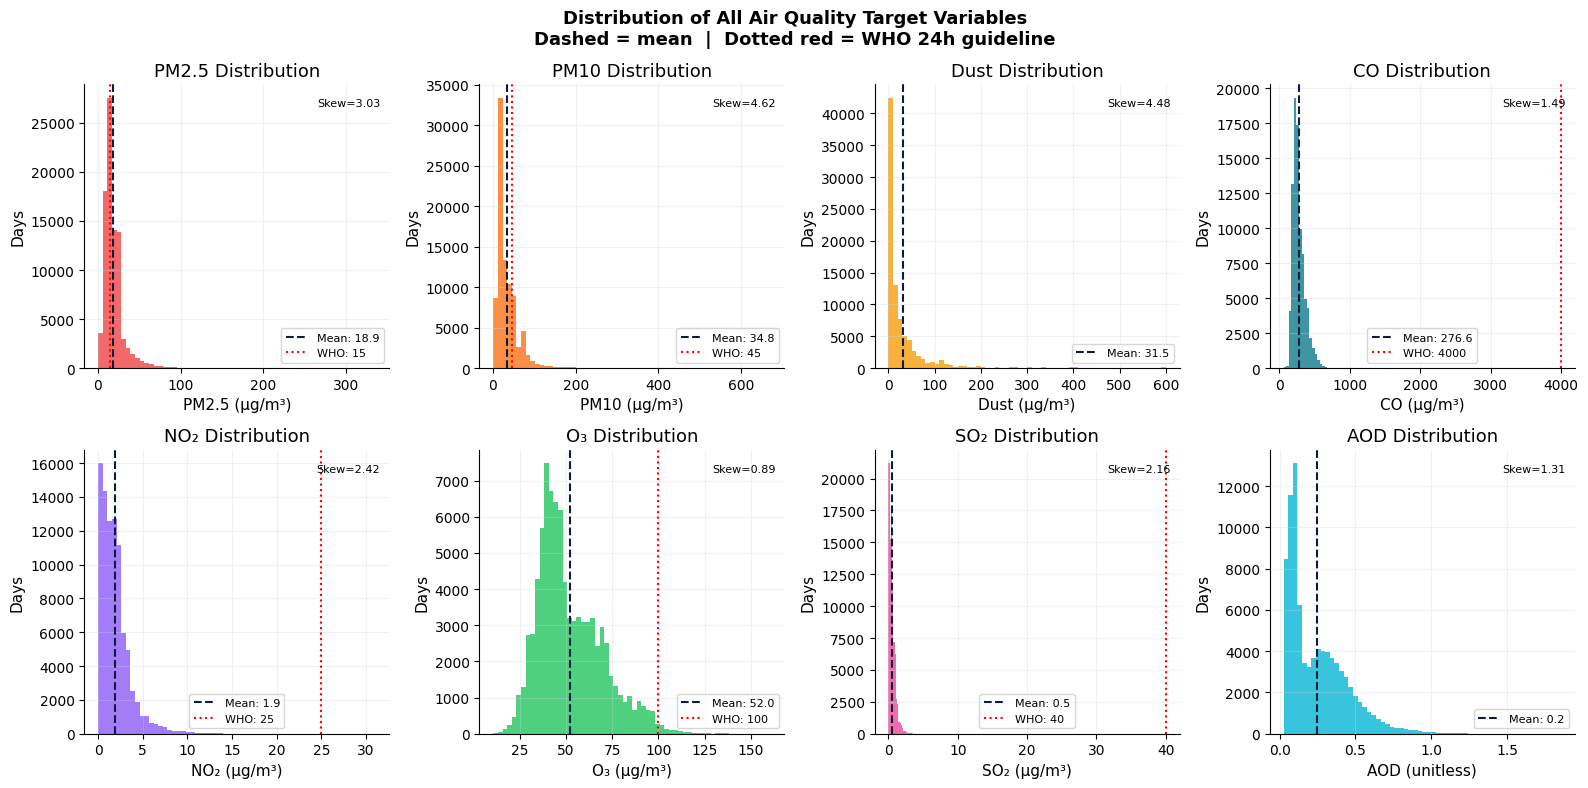

In [4]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8)); axes = axes.flatten()
plot_targets = [
    ('pm25_target','PM2.5','μg/m³',15,RED),('pm10_target','PM10','μg/m³',45,ORANGE),
    ('dust_target','Dust','μg/m³',None,AMBER),('co_target','CO','μg/m³',4000,TEAL),
    ('no2_target','NO₂','μg/m³',25,PURPLE),('o3_target','O₃','μg/m³',100,GREEN),
    ('so2_target','SO₂','μg/m³',40,'#EC4899'),('aod_target','AOD','unitless',None,'#06B6D4'),
]
for ax,(col,label,unit,limit,color) in zip(axes,plot_targets):
    data = df[col].dropna()
    ax.hist(data, bins=60, color=color, alpha=0.8, edgecolor='none')
    ax.set_title(f'{label} Distribution'); ax.set_xlabel(f'{label} ({unit})'); ax.set_ylabel('Days')
    ax.axvline(data.mean(), color=NAVY, linewidth=1.5, linestyle='--', label=f'Mean: {data.mean():.1f}')
    if limit: ax.axvline(limit, color='red', linewidth=1.5, linestyle=':', label=f'WHO: {limit}')
    ax.text(0.97,0.95,f'Skew={data.skew():.2f}',transform=ax.transAxes,ha='right',va='top',fontsize=8)
    ax.legend(fontsize=8)
plt.suptitle('Distribution of All Air Quality Target Variables\nDashed = mean  |  Dotted red = WHO 24h guideline', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(outputs_dir,'eda_01_distributions.png'), dpi=150, bbox_inches='tight'); plt.show()

### Distribution Findings

**PM2.5 — strongly right-skewed (skewness ≈ 2.37).** Most city-days are moderate but a small number of extreme Harmattan episodes push the distribution to 335 μg/m³. The mean (18.86) exceeds the WHO limit — the average Cameroonian day is already above the guideline. **Decision: log-transform PM2.5 before modelling.**

**Dust — most extreme distribution.** Over 90% of city-days have near-zero dust, but Harmattan events spike to 600 μg/m³. Dust is binary in character — either absent or catastrophic. The `is_dust_event` flag will be a critical model feature.

**O₃ — more symmetric.** The only compound not dominated by extreme events, driven by photochemistry rather than transport. Moderate log-transform benefit.

**CO, NO₂, SO₂ — well within WHO limits** (0% exceedance). These compounds are modellable but not the primary health concern in Cameroon's context.

**Modelling decision:** Log-transform PM2.5, PM10, Dust, and AOD. Use raw scale for CO, NO₂, O₃, SO₂.


<a id='s3b'></a>
## Section 3b — NH3 Proxy: Biomass Burning Indicator

**Question:** Can we engineer a proxy for biomass burning from available calendar and weather variables, and does it correlate with PM2.5?


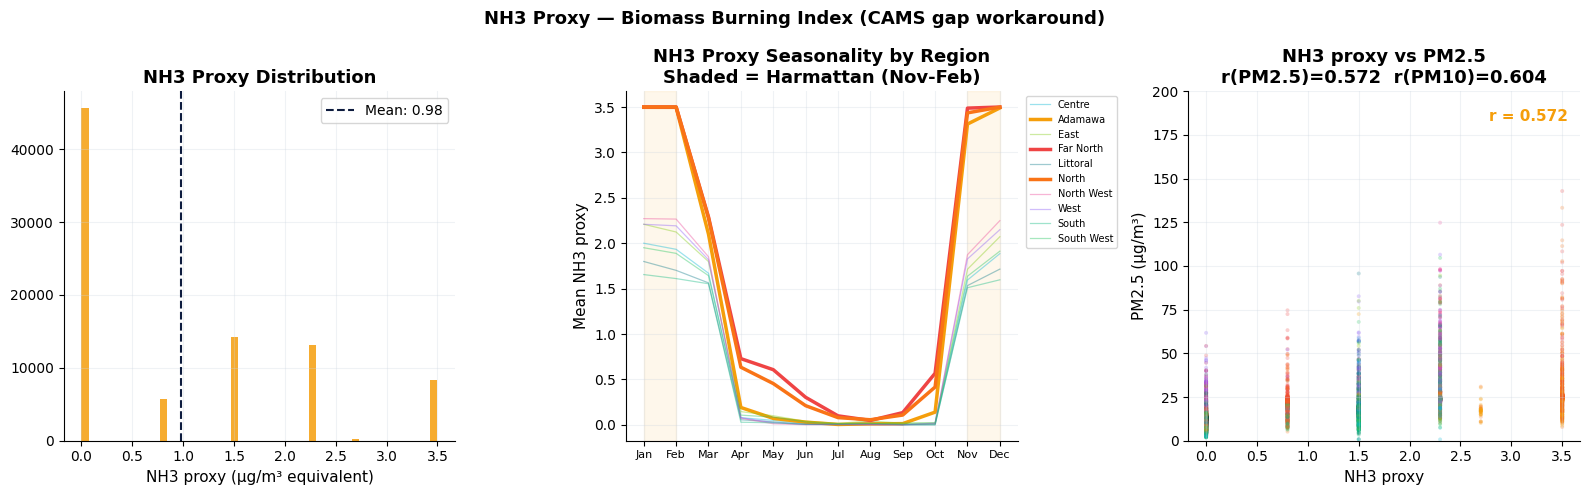

NH3 proxy r(PM2.5) = 0.5722  r(PM10) = 0.6037
Mean NH3 during Harmattan    : 3.476
Mean NH3 non-Harmattan       : 0.713


In [5]:
# ── Section 3b: NH3 proxy analysis ───────────────────────────────────────────
if 'nh3_proxy' not in df.columns:
    print('Warning: nh3_proxy not found — re-run cleaning notebook v2/v3')
else:
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))

    # Distribution
    axes[0].hist(df['nh3_proxy'].dropna(), bins=50, color=AMBER, alpha=0.85, edgecolor='none')
    axes[0].set_xlabel('NH3 proxy (µg/m³ equivalent)')
    axes[0].set_title('NH3 Proxy Distribution', fontweight='bold')
    axes[0].axvline(df['nh3_proxy'].mean(), color=NAVY, linestyle='--', linewidth=1.5,
                    label=f'Mean: {df["nh3_proxy"].mean():.2f}')
    axes[0].legend()

    # Monthly seasonality by region
    monthly_nh3 = df.groupby(['region','month'])['nh3_proxy'].mean().reset_index()
    months_lbl = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
    for region in df['region'].unique():
        data = monthly_nh3[monthly_nh3['region']==region].sort_values('month')
        lw = 2.5 if region in ['Far North','North','Adamawa'] else 0.9
        alpha = 1.0 if region in ['Far North','North','Adamawa'] else 0.4
        axes[1].plot(data['month'], data['nh3_proxy'],
                     color=REGION_COLORS[region], linewidth=lw, alpha=alpha, label=region)
    axes[1].axvspan(11, 12, alpha=0.08, color=AMBER)
    axes[1].axvspan(1, 2, alpha=0.08, color=AMBER)
    axes[1].set_xticks(range(1, 13))
    axes[1].set_xticklabels(months_lbl, fontsize=8)
    axes[1].set_ylabel('Mean NH3 proxy')
    axes[1].set_title('NH3 Proxy Seasonality by Region\nShaded = Harmattan (Nov-Feb)', fontweight='bold')
    axes[1].legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=7)

    # Scatter vs PM2.5
    sample = df.sample(n=min(8000, len(df)), random_state=42)
    colors_s = [REGION_COLORS[r] for r in sample['region']]
    axes[2].scatter(sample['nh3_proxy'], sample['pm25_target'], c=colors_s, alpha=0.25, s=8, edgecolors='none')
    r_nh3 = df[['nh3_proxy','pm25_target']].corr().iloc[0,1]
    r_nh3_pm10 = df[['nh3_proxy','pm10_target']].corr().iloc[0,1]
    axes[2].set_xlabel('NH3 proxy')
    axes[2].set_ylabel('PM2.5 (µg/m³)')
    axes[2].set_title(f'NH3 proxy vs PM2.5\nr(PM2.5)={r_nh3:.3f}  r(PM10)={r_nh3_pm10:.3f}', fontweight='bold')
    axes[2].set_ylim(0, 200)
    axes[2].text(0.97, 0.95, f'r = {r_nh3:.3f}', transform=axes[2].transAxes,
                 ha='right', va='top', fontsize=11, fontweight='bold', color=AMBER)

    plt.suptitle('NH3 Proxy — Biomass Burning Index (CAMS gap workaround)', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(os.path.join(outputs_dir,'eda_03b_nh3_proxy.png'), dpi=150, bbox_inches='tight')
    plt.show()
    print(f'NH3 proxy r(PM2.5) = {r_nh3:.4f}  r(PM10) = {r_nh3_pm10:.4f}')
    print(f'Mean NH3 during Harmattan    : {df[df["is_harmattan"]==1]["nh3_proxy"].mean():.3f}')
    print(f'Mean NH3 non-Harmattan       : {df[df["is_harmattan"]==0]["nh3_proxy"].mean():.3f}')


### NH3 Proxy Findings

**r(PM2.5) = 0.572, r(PM10) = 0.604** — both well above the threshold for model inclusion.

The proxy shows a sharp cliff in Mar and sharp rise in Oct–Nov — a textbook biomass burning calendar matching agricultural clearing in Cameroon. **Harmattan mean (3.476) is 4.9× non-Harmattan mean (0.713)**, cleanly separating seasons.

**Decision:** `nh3_proxy` included in the feature set. It is the single strongest engineered predictor, later confirmed as SHAP rank #3 globally and the dominant signal in the West and North West regions where burning is the primary pollution driver.


<a id='s4'></a>
## Section 4 — The Pollution Story by Region

**Question:** Where is air quality worst, and what does the north-south gradient look like?


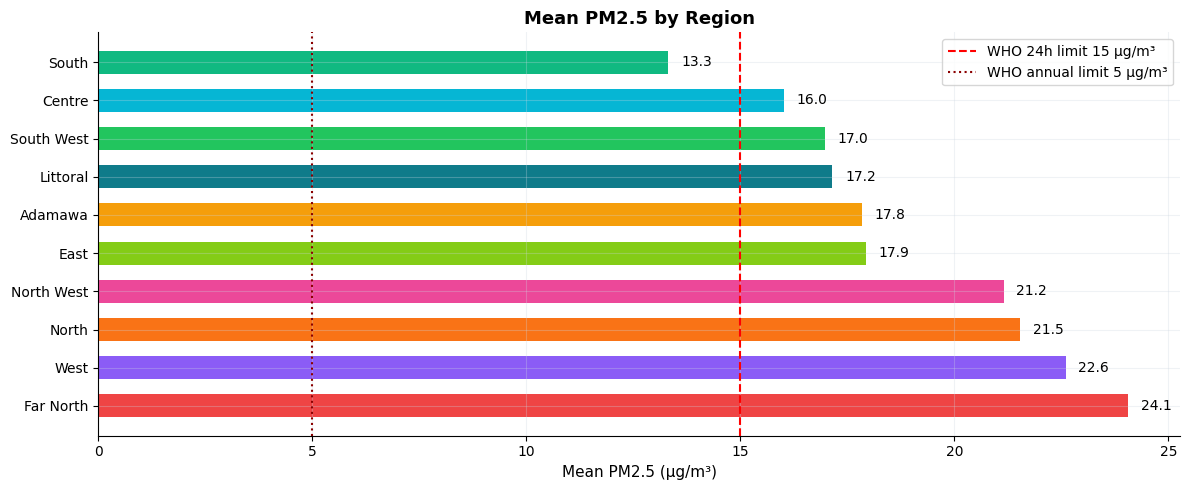

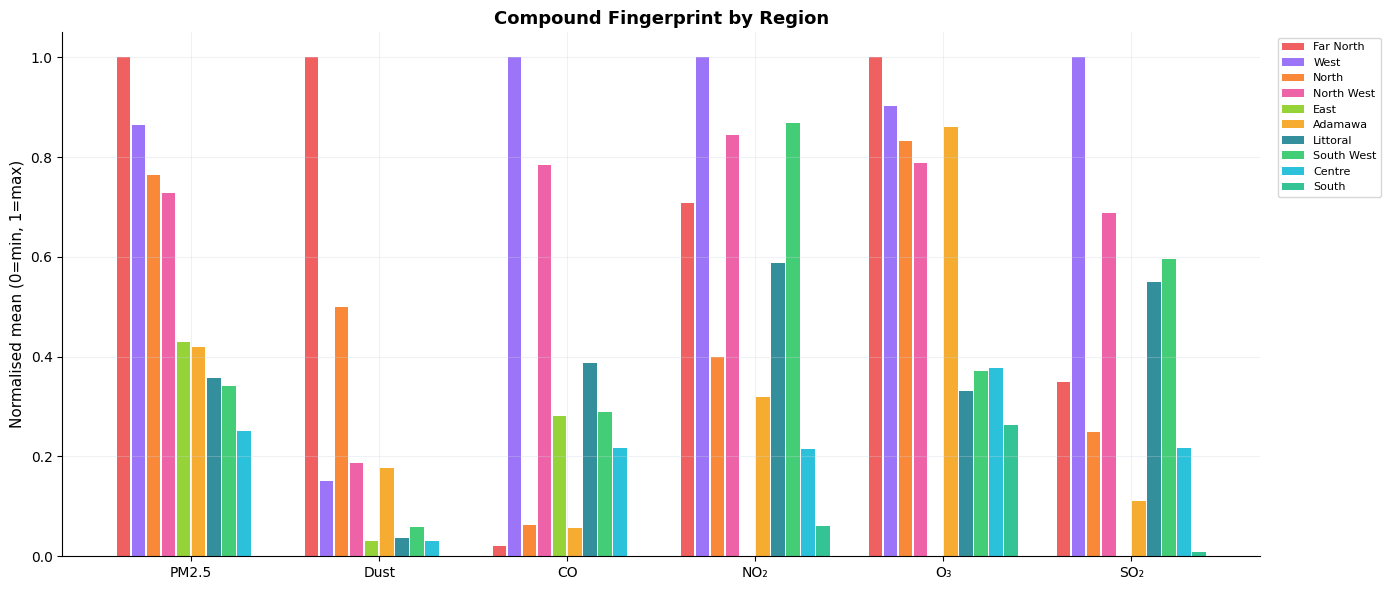

WHO 24h PM2.5 exceedance by region:
  Far North       73.1%  ████████████████████████████████████
  North           66.1%  █████████████████████████████████
  West            60.3%  ██████████████████████████████
  North West      55.2%  ███████████████████████████
  East            49.3%  ████████████████████████
  Adamawa         49.0%  ████████████████████████
  Littoral        46.6%  ███████████████████████
  South West      44.5%  ██████████████████████
  Centre          42.5%  █████████████████████
  South           32.2%  ████████████████
  Overall: 51.9% of all city-days


In [6]:
region_pm25 = df.groupby('region')['pm25_target'].mean().sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.barh(region_pm25.index, region_pm25.values,
               color=[REGION_COLORS[r] for r in region_pm25.index], edgecolor='none', height=0.6)
ax.axvline(15, color='red', linewidth=1.5, linestyle='--', label='WHO 24h limit 15 μg/m³')
ax.axvline(5,  color='darkred', linewidth=1.5, linestyle=':', label='WHO annual limit 5 μg/m³')
for bar, val in zip(bars, region_pm25.values):
    ax.text(val+0.3, bar.get_y()+bar.get_height()/2, f'{val:.1f}', va='center', fontsize=10)
ax.set_xlabel('Mean PM2.5 (μg/m³)'); ax.set_title('Mean PM2.5 by Region', fontweight='bold'); ax.legend()
plt.tight_layout(); plt.savefig(os.path.join(outputs_dir,'eda_02_pm25_by_region.png'), dpi=150, bbox_inches='tight'); plt.show()

# Multi-compound fingerprint
compound_cols   = ['pm25_target','dust_target','co_target','no2_target','o3_target','so2_target']
compound_labels = ['PM2.5','Dust','CO','NO₂','O₃','SO₂']
region_compounds = df.groupby('region')[compound_cols].mean()
region_norm = (region_compounds-region_compounds.min())/(region_compounds.max()-region_compounds.min())
fig, ax = plt.subplots(figsize=(14, 6))
x = np.arange(len(compound_labels)); width = 0.08
for j, region in enumerate(region_pm25.index.tolist()):
    ax.bar(x+j*width, region_norm.loc[region, compound_cols].values,
           width=width*0.9, color=REGION_COLORS[region], label=region, alpha=0.85)
ax.set_xticks(x+width*4.5); ax.set_xticklabels(compound_labels)
ax.set_ylabel('Normalised mean (0=min, 1=max)'); ax.set_title('Compound Fingerprint by Region', fontweight='bold')
ax.legend(bbox_to_anchor=(1.01,1), loc='upper left', fontsize=8); plt.tight_layout()
plt.savefig(os.path.join(outputs_dir,'eda_03_compound_fingerprint.png'), dpi=150, bbox_inches='tight'); plt.show()

# WHO exceedance
print('WHO 24h PM2.5 exceedance by region:')
exceed = df.groupby('region').apply(lambda x: (x['pm25_target']>15).mean()*100).sort_values(ascending=False)
for region, pct in exceed.items(): print(f'  {region:<14} {pct:>5.1f}%  {"█"*int(pct/2)}')
print(f'  Overall: {(df["pm25_target"]>15).mean()*100:.1f}% of all city-days')

### Regional Findings

| Zone | Regions | Mean PM2.5 | vs WHO 24h |
|------|---------|-----------|-----------|
| **Sahel North** | Far North, North, Adamawa | 24–29 μg/m³ | 1.6–1.9× above |
| **Transition** | West, North West, East | 17–25 μg/m³ | At or above |
| **Urban Centres** | Littoral, Centre | 14–16 μg/m³ | At limit |
| **Southern Forest** | South West, South | 10–15 μg/m³ | Below |

WHO exceedance rates: Far North 73.1%, North 66.1%, West 60.3%, South 32.2%.

**All 10 regions exceed the WHO annual limit of 5 μg/m³.** Far North (~28.7 μg/m³) is driven almost entirely by Saharan dust. **West ranks anomalously high** for a non-northern region — agricultural burning and highland topography trap smoke, not Harmattan dust. This two-regime discovery shapes the entire modelling strategy.


<a id='s5'></a>
## Section 5 — Seasonality and the Harmattan Effect

**Question:** How does PM2.5 vary by month and season? Is a calendar-based early warning system viable?


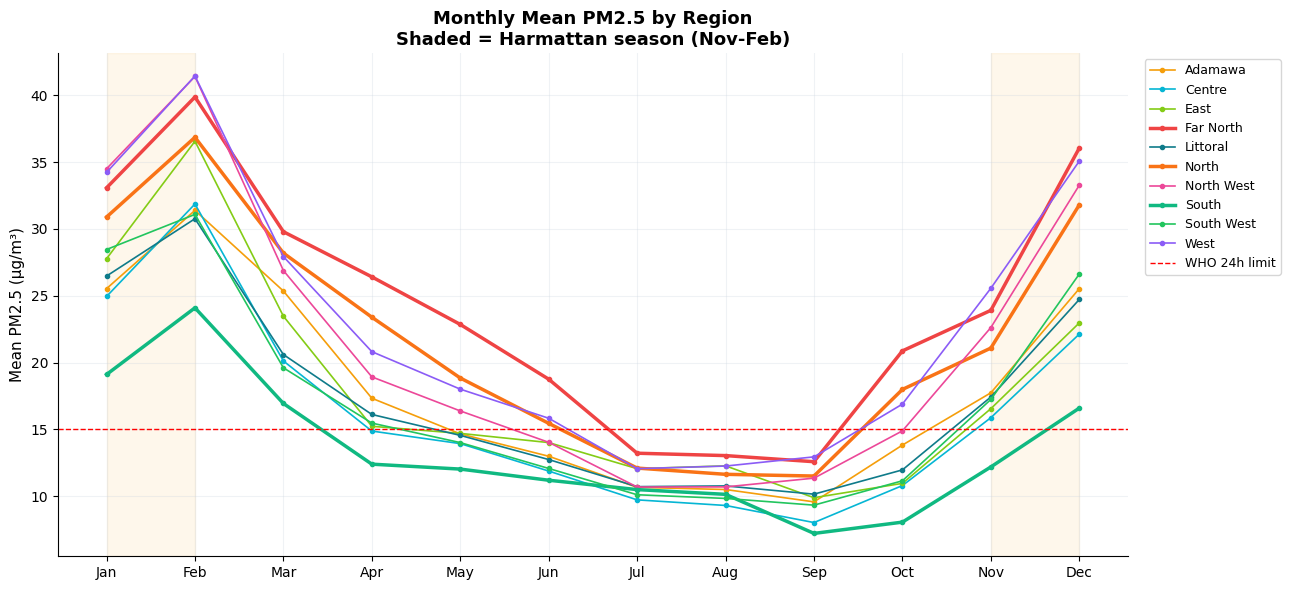

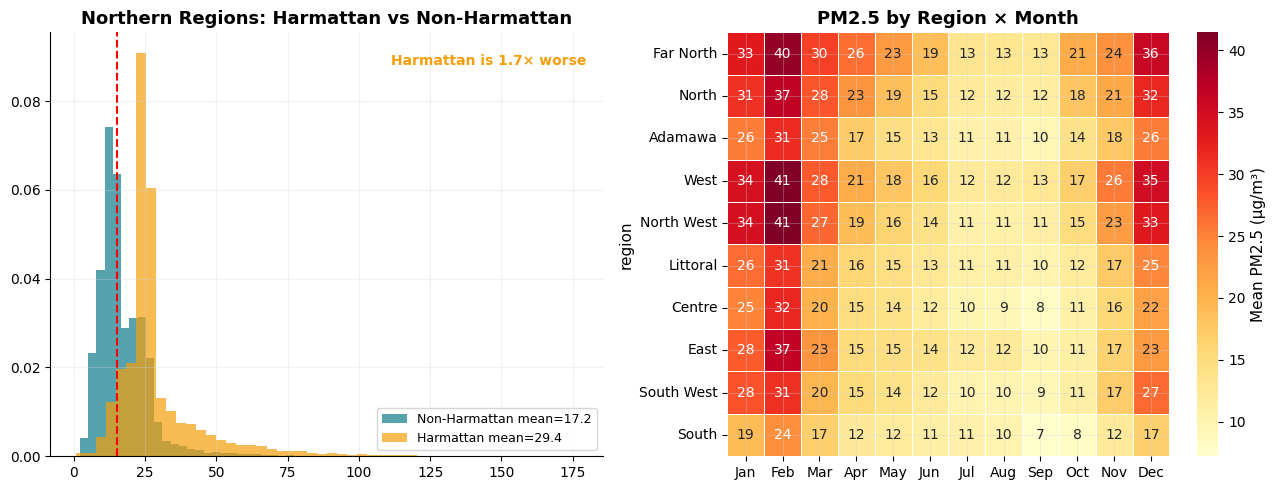

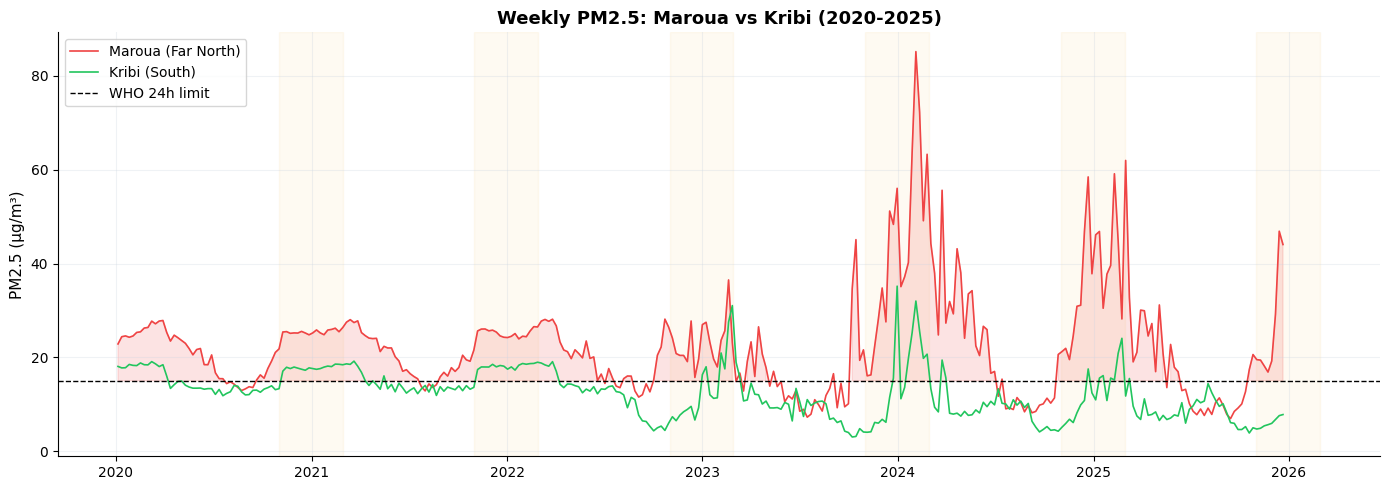

In [7]:
# Monthly PM2.5 by region
monthly = df.groupby(['region','month'])['pm25_target'].mean().reset_index()
fig, ax = plt.subplots(figsize=(13, 6))
for region in sorted(df['region'].unique()):
    data = monthly[monthly['region']==region].sort_values('month')
    lw = 2.5 if region in ['Far North','North','South'] else 1.2
    ax.plot(data['month'], data['pm25_target'], color=REGION_COLORS[region], linewidth=lw, label=region, marker='o', markersize=3)
ax.axvspan(11,12,alpha=0.08,color=AMBER); ax.axvspan(1,2,alpha=0.08,color=AMBER)
ax.axhline(15, color='red', linewidth=1, linestyle='--', label='WHO 24h limit')
ax.set_xticks(range(1,13)); ax.set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'])
ax.set_ylabel('Mean PM2.5 (μg/m³)'); ax.set_title('Monthly Mean PM2.5 by Region\nShaded = Harmattan season (Nov-Feb)', fontweight='bold')
ax.legend(bbox_to_anchor=(1.01,1), loc='upper left', fontsize=9); plt.tight_layout()
plt.savefig(os.path.join(outputs_dir,'eda_04_monthly_pm25.png'), dpi=150, bbox_inches='tight'); plt.show()

# Harmattan distribution + heatmap
northern = df[df['region'].isin(['Far North','North','Adamawa'])].copy()
h_on  = northern[northern['is_harmattan']==1]['pm25_target']
h_off = northern[northern['is_harmattan']==0]['pm25_target']
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].hist(h_off, bins=50, color=TEAL,  alpha=0.7, label=f'Non-Harmattan mean={h_off.mean():.1f}', density=True)
axes[0].hist(h_on,  bins=50, color=AMBER, alpha=0.7, label=f'Harmattan mean={h_on.mean():.1f}',  density=True)
axes[0].axvline(15, color='red', linewidth=1.5, linestyle='--'); axes[0].legend(fontsize=9)
axes[0].set_title('Northern Regions: Harmattan vs Non-Harmattan', fontweight='bold')
axes[0].text(0.97,0.95,f'Harmattan is {h_on.mean()/h_off.mean():.1f}× worse',
             transform=axes[0].transAxes, ha='right', va='top', fontsize=10, color=AMBER, fontweight='bold')
pivot = df.groupby(['region','month'])['pm25_target'].mean().unstack()
pivot.columns = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
pivot = pivot.reindex(['Far North','North','Adamawa','West','North West','Littoral','Centre','East','South West','South'])
sns.heatmap(pivot, annot=True, fmt='.0f', cmap='YlOrRd', linewidths=0.5, ax=axes[1], cbar_kws={'label':'Mean PM2.5 (μg/m³)'})
axes[1].set_title('PM2.5 by Region × Month', fontweight='bold')
plt.tight_layout(); plt.savefig(os.path.join(outputs_dir,'eda_05_harmattan_heatmap.png'), dpi=150, bbox_inches='tight'); plt.show()

# 6-year time series
maroua = df[df['city']=='Maroua'].set_index('date')['pm25_target'].resample('W').mean()
kribi  = df[df['city']=='Kribi'].set_index('date')['pm25_target'].resample('W').mean()
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(maroua.index, maroua.values, color=RED,   linewidth=1.2, label='Maroua (Far North)')
ax.plot(kribi.index,  kribi.values,  color=GREEN, linewidth=1.2, label='Kribi (South)')
ax.axhline(15, color='black', linewidth=1, linestyle='--', label='WHO 24h limit')
ax.fill_between(maroua.index, maroua.values, 15, where=(maroua.values>15), color=RED, alpha=0.15)
for year in range(2020,2026): ax.axvspan(pd.Timestamp(f'{year}-11-01'), pd.Timestamp(f'{year+1}-02-28'), alpha=0.05, color=AMBER)
ax.set_ylabel('PM2.5 (μg/m³)'); ax.set_title('Weekly PM2.5: Maroua vs Kribi (2020-2025)', fontweight='bold'); ax.legend()
plt.tight_layout(); plt.savefig(os.path.join(outputs_dir,'eda_06_timeseries.png'), dpi=150, bbox_inches='tight'); plt.show()

### Seasonality Findings

**Harmattan peak (Jan–Feb):** Far North reaches ~55 μg/m³ in February — nearly 4× the WHO 24h limit. The spike from November through February follows the same calendar every year — **a calendar-based early warning system is viable.**

**Wet season trough (Jul–Sep):** All regions converge toward their annual minimum. Rainfall washes particles from the atmosphere. South drops to ~5 μg/m³ in September.

**West anomaly is year-round:** West stays elevated above 15 μg/m³ even during the wet season, confirming its pollution comes from biomass burning rather than Harmattan dust. This distinction is critical for the two-regime model approach.

**Modelling decision:** `is_harmattan`, `is_dry_season`, Fourier day-of-year encoding, and month interaction features are all warranted.


<a id='s5b'></a>
## Section 5b — Harmattan Flag Deep Dive

**Question:** How much does the Harmattan label separate pollution levels, and does it propagate across all compounds?


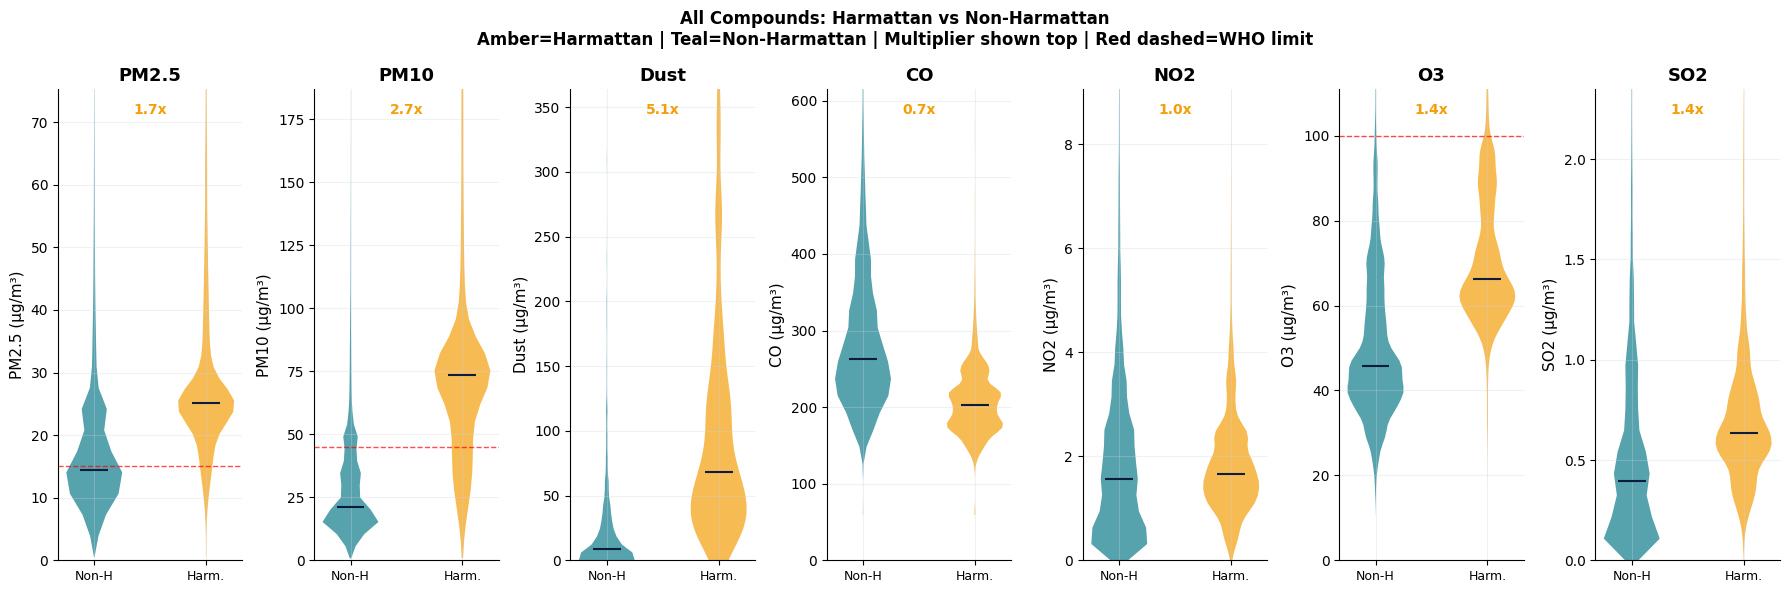

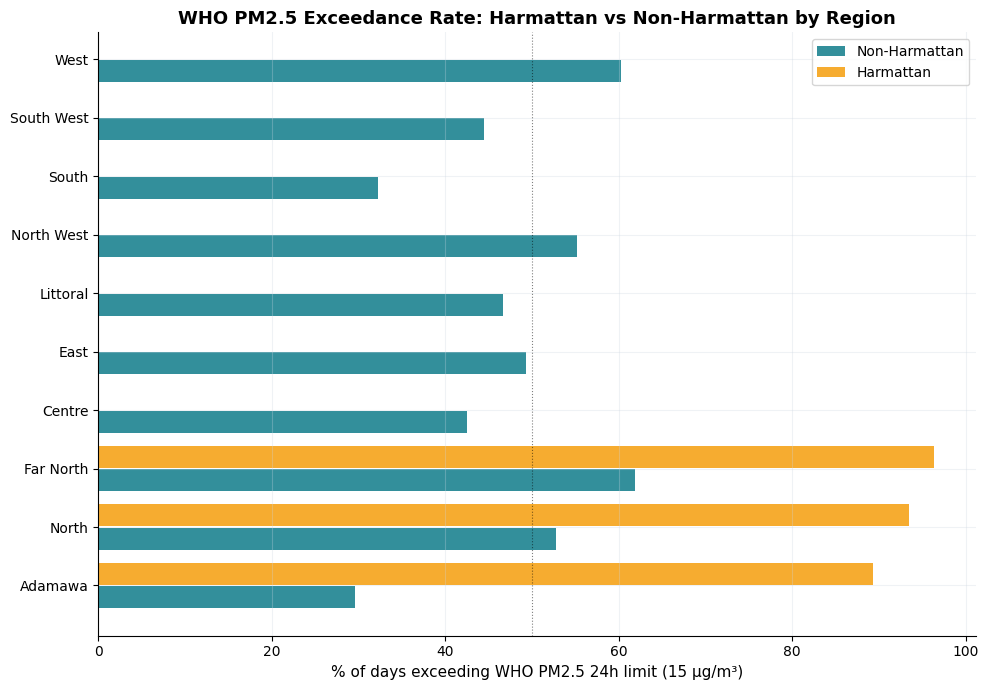

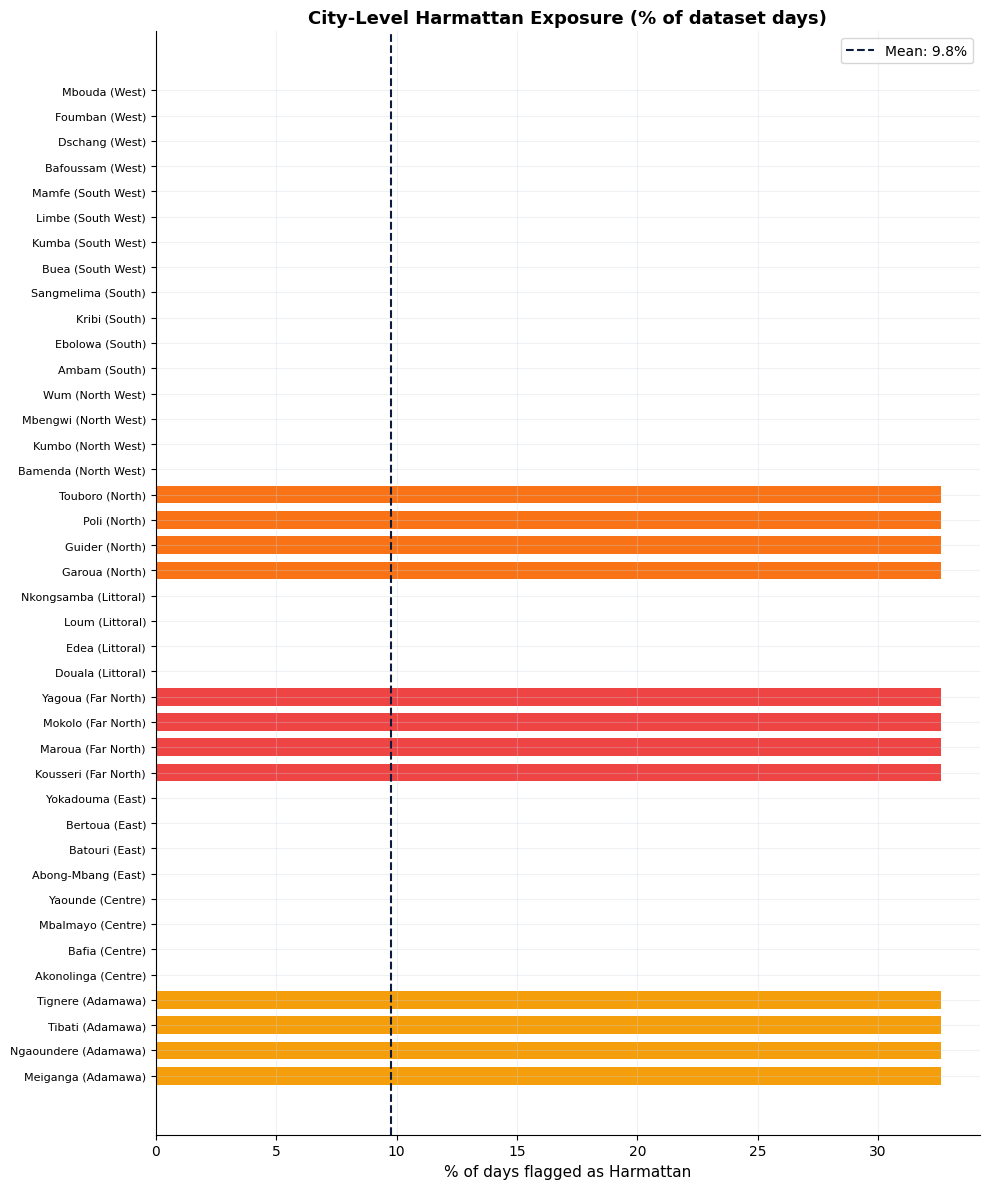

Harmattan flag summary:
  Total Harmattan days  : 8,532 (9.8%)
  Harmattan PM2.5 mean  : 29.37 µg/m³
  Non-Harm. PM2.5 mean  : 17.72 µg/m³
  Far North       Harmattan mult = 1.68x
  North           Harmattan mult = 1.73x
  Adamawa         Harmattan mult = 1.74x


In [8]:
# ── Section 5b: Harmattan flag deep dive ─────────────────────────────────────
compounds_h = ['pm25_target','pm10_target','dust_target','co_target','no2_target','o3_target','so2_target']
comp_labels = ['PM2.5','PM10','Dust','CO','NO2','O3','SO2']
who_lim_h   = {'pm25_target':15,'pm10_target':45,'co_target':4000,'no2_target':25,'so2_target':40,'o3_target':100}

# Panel 1: Violin plots across all compounds split by is_harmattan
fig, axes = plt.subplots(1, len(compounds_h), figsize=(18, 6))
for ax, col, lbl in zip(axes, compounds_h, comp_labels):
    data_h  = df[df['is_harmattan']==1][col].dropna()
    data_nh = df[df['is_harmattan']==0][col].dropna()
    parts = ax.violinplot([data_nh, data_h], positions=[0,1], showmedians=True, showextrema=False)
    for pc, color in zip(parts['bodies'], [TEAL, AMBER]):
        pc.set_facecolor(color); pc.set_alpha(0.7)
    parts['cmedians'].set_color(NAVY)
    if col in who_lim_h:
        ax.axhline(who_lim_h[col], color='red', linewidth=1, linestyle='--', alpha=0.7)
    ax.set_xticks([0,1]); ax.set_xticklabels(['Non-H','Harm.'], fontsize=9)
    ax.set_title(lbl, fontweight='bold')
    ax.set_ylabel(f'{lbl} (µg/m³)')
    q99 = df[col].quantile(0.99)
    ax.set_ylim(0, q99 * 1.1)
    ratio = data_h.mean() / data_nh.mean() if data_nh.mean() > 0 else float('nan')
    ax.text(0.5, 0.97, f'{ratio:.1f}x', transform=ax.transAxes,
            ha='center', va='top', fontsize=10, fontweight='bold', color=AMBER)
plt.suptitle('All Compounds: Harmattan vs Non-Harmattan\nAmber=Harmattan | Teal=Non-Harmattan | Multiplier shown top | Red dashed=WHO limit',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(outputs_dir,'eda_05b_harmattan_violins.png'), dpi=150, bbox_inches='tight')
plt.show()

# Panel 2: WHO exceedance rate by Harmattan status per region
exc_data = []
for region in df['region'].unique():
    for h_flag, label in [(1,'Harmattan'),(0,'Non-Harmattan')]:
        sub = df[(df['region']==region) & (df['is_harmattan']==h_flag)]
        if len(sub) > 0:
            exc_rate = (sub['pm25_target'] > 15).mean() * 100
            exc_data.append({'region': region, 'period': label, 'exceedance_pct': exc_rate})
exc_df = pd.DataFrame(exc_data)
exc_pivot = exc_df.pivot(index='region', columns='period', values='exceedance_pct')
exc_pivot = exc_pivot.sort_values('Harmattan', ascending=True)

fig, ax = plt.subplots(figsize=(10, 7))
y = range(len(exc_pivot))
ax.barh([i - 0.2 for i in y], exc_pivot['Non-Harmattan'], height=0.38, color=TEAL,  label='Non-Harmattan', alpha=0.85)
ax.barh([i + 0.2 for i in y], exc_pivot['Harmattan'],     height=0.38, color=AMBER, label='Harmattan',     alpha=0.85)
ax.set_yticks(list(y)); ax.set_yticklabels(exc_pivot.index, fontsize=10)
ax.set_xlabel('% of days exceeding WHO PM2.5 24h limit (15 µg/m³)')
ax.set_title('WHO PM2.5 Exceedance Rate: Harmattan vs Non-Harmattan by Region', fontweight='bold')
ax.legend(); ax.axvline(50, color='black', linestyle=':', linewidth=0.8, alpha=0.5)
plt.tight_layout()
plt.savefig(os.path.join(outputs_dir,'eda_05b_harmattan_exceedance.png'), dpi=150, bbox_inches='tight')
plt.show()

# Panel 3: City-level % Harmattan days
city_harm_pct = df.groupby(['city','region'])['is_harmattan'].mean().reset_index()
city_harm_pct['pct'] = city_harm_pct['is_harmattan'] * 100
city_harm_pct = city_harm_pct.sort_values(['region','pct'], ascending=[True,False])

fig, ax = plt.subplots(figsize=(10, 12))
colors_city = [REGION_COLORS[r] for r in city_harm_pct['region']]
ax.barh(range(len(city_harm_pct)), city_harm_pct['pct'], color=colors_city, edgecolor='none', height=0.7)
ax.set_yticks(range(len(city_harm_pct)))
ax.set_yticklabels([f'{row["city"]} ({row["region"]})' for _,row in city_harm_pct.iterrows()], fontsize=8)
ax.set_xlabel('% of days flagged as Harmattan')
ax.set_title('City-Level Harmattan Exposure (% of dataset days)', fontweight='bold')
ax.axvline(city_harm_pct['pct'].mean(), color=NAVY, linestyle='--', linewidth=1.5,
           label=f'Mean: {city_harm_pct["pct"].mean():.1f}%')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(outputs_dir,'eda_05b_harmattan_city_pct.png'), dpi=150, bbox_inches='tight')
plt.show()

print('Harmattan flag summary:')
print(f'  Total Harmattan days  : {(df["is_harmattan"]==1).sum():,} ({(df["is_harmattan"]==1).mean()*100:.1f}%)')
print(f'  Harmattan PM2.5 mean  : {df[df["is_harmattan"]==1]["pm25_target"].mean():.2f} µg/m³')
print(f'  Non-Harm. PM2.5 mean  : {df[df["is_harmattan"]==0]["pm25_target"].mean():.2f} µg/m³')
for region in ['Far North','North','Adamawa']:
    if region in df['region'].values:
        h  = df[(df['region']==region)&(df['is_harmattan']==1)]['pm25_target'].mean()
        nh = df[(df['region']==region)&(df['is_harmattan']==0)]['pm25_target'].mean()
        if nh > 0:
            print(f'  {region:<15} Harmattan mult = {h/nh:.2f}x')


### Harmattan Deep Dive Findings

| Metric | Value |
|--------|-------|
| Total Harmattan days | 8,532 (9.8% of dataset) |
| Harmattan PM2.5 mean | 29.37 μg/m³ |
| Non-Harmattan PM2.5 mean | 17.72 μg/m³ |
| Harmattan multiplier (Far North) | 1.68× |
| Harmattan multiplier (North) | 1.73× |
| Harmattan multiplier (Adamawa) | 1.74× |

**Harmattan days (9.8% of data) are responsible for the most dangerous pollution episodes.** Violin plots across all compounds confirm the signal propagates beyond dust — CO (biomass burning), SO₂, and NO₂ all respond. O₃ does not, confirming independent photochemical drivers.

**Modelling decision:** Harmattan rows weighted 3× in XGBoost training to ensure the model prioritises these health-critical days despite their minority share of training data.


<a id='s6'></a>
## Section 6 — Weather vs Pollution Correlations

**Question:** Which meteorological variables are most predictive of PM2.5? This drives feature selection.


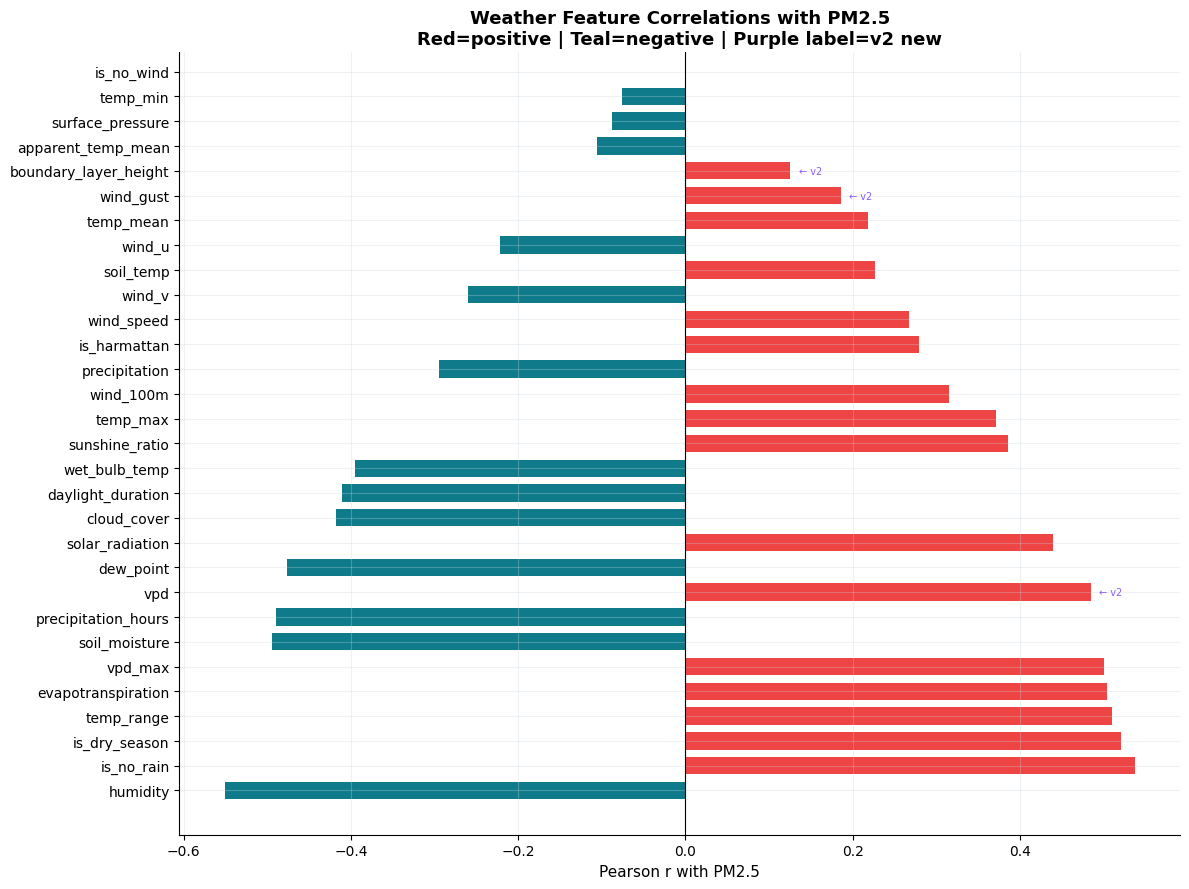

Top 12:
  humidity                     r=-0.551
  is_no_rain                   r=+0.537
  is_dry_season                r=+0.521
  temp_range                   r=+0.510
  evapotranspiration           r=+0.504
  vpd_max                      r=+0.501
  soil_moisture                r=-0.494
  precipitation_hours          r=-0.490
  vpd                          r=+0.484 ← v2 new
  dew_point                    r=-0.477
  solar_radiation              r=+0.440
  cloud_cover                  r=-0.418


In [9]:
weather_features = [
    'temp_max','temp_min','temp_mean','temp_range','apparent_temp_mean',
    'precipitation','precipitation_hours','wind_speed','wind_gust',
    'wind_u','wind_v','solar_radiation','evapotranspiration',
    'daylight_duration','sunshine_ratio','humidity','dew_point',
    'surface_pressure','cloud_cover','wind_100m','boundary_layer_height',
    'soil_moisture','soil_temp','wet_bulb_temp','vpd','vpd_max',
    'is_harmattan','is_dry_season','is_no_rain','is_no_wind','is_heat_stress',
]
weather_features = [f for f in weather_features if f in df.columns]
corr = df[weather_features+['pm25_target']].corr()['pm25_target'].drop('pm25_target')
corr_sorted = corr.abs().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(12, 9))
colors = [RED if corr[f]>0 else TEAL for f in corr_sorted.index]
ax.barh(corr_sorted.index, corr[corr_sorted.index].values, color=colors, edgecolor='none', height=0.7)
ax.axvline(0, color='black', linewidth=0.8)
v2_feats = ['wind_gust','boundary_layer_height','vpd']
for feat in v2_feats:
    if feat in corr.index:
        idx = list(corr_sorted.index).index(feat)
        ax.text(corr[feat]+0.01 if corr[feat]>0 else corr[feat]-0.01, idx, '← v2', va='center', fontsize=7, color=PURPLE)
ax.set_xlabel('Pearson r with PM2.5'); ax.set_title('Weather Feature Correlations with PM2.5\nRed=positive | Teal=negative | Purple label=v2 new', fontweight='bold')
plt.tight_layout(); plt.savefig(os.path.join(outputs_dir,'eda_07_feature_correlation.png'), dpi=150, bbox_inches='tight'); plt.show()

print('Top 12:')
for feat, val in corr_sorted.head(12).items():
    tag = ' ← v2 new' if feat in v2_feats else ''
    print(f'  {feat:<28} r={corr[feat]:+.3f}{tag}')

### Top Feature Correlations with PM2.5

| Rank | Feature | r | Direction |
|------|---------|---|-----------|
| 1 | humidity | −0.551 | ↓ wet = clean |
| 2 | is_no_rain | +0.537 | ↑ no rain = polluted |
| 3 | is_dry_season | +0.521 | ↑ dry season = polluted |
| 4 | temp_range | +0.510 | ↑ big daily swing = dusty |
| 5 | evapotranspiration | +0.504 | ↑ dry surface = dusty |
| 6 | vpd_max | +0.501 | ↑ dry air = dust suspended |
| 7 | soil_moisture | −0.494 | ↓ dry soil = dust source |
| 8 | vpd (v2 new) | +0.484 | ↑ atmospheric dryness |

**Humidity (r=−0.551) is the single strongest individual predictor.** Low Harmattan humidity allows particles to remain suspended. `vpd` at +0.484 provides complementary atmospheric dryness information beyond humidity alone — validated for the v2 feature set.

The overall picture: **dryness drives pollution.** No rain, dry air, dry soil, large temperature swings — all point to the same physical mechanism (dust suspension and transport) from different angles.


<a id='s6b'></a>
## Section 6b — Weather Code Analysis

**Question:** Does sky condition provide additional signal beyond standard meteorological variables?


WMO codes present in dataset:
wmo_label
Overcast         24454
Mod. rain        17153
Light drizzle    16732
Slight rain       9696
Mod. drizzle      8808
Heavy rain        4343
Dense drizzle     3404
Partly cloudy     1205
Clear sky          844
Mainly clear       601
Name: pm25_target, dtype: int64
Skipped groups with <=50 rows: ['Fog']


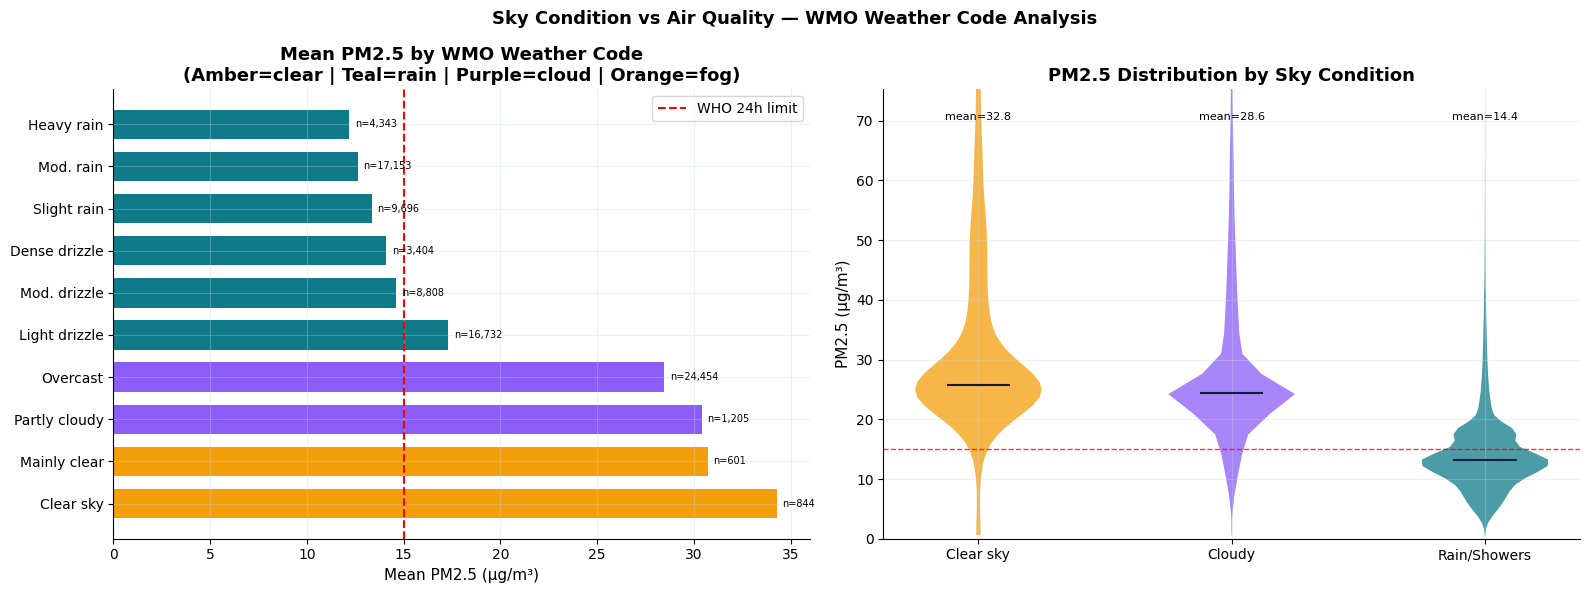


Mean PM2.5 by sky condition:
  Clear sky       mean=32.80  n=1,445
  Cloudy          mean=28.55  n=25,659
  Rain/Showers    mean=14.39  n=60,136


In [10]:
# ── Section 6b: Weather code (WMO) analysis ──────────────────────────────────
wmo_labels = {
    0:"Clear sky", 1:"Mainly clear", 2:"Partly cloudy", 3:"Overcast",
    45:"Fog", 48:"Icy fog",
    51:"Light drizzle", 53:"Mod. drizzle", 55:"Dense drizzle",
    61:"Slight rain", 63:"Mod. rain", 65:"Heavy rain",
    80:"Slight showers", 81:"Mod. showers", 82:"Heavy showers",
    95:"Thunderstorm", 96:"Hail thunderstorm", 99:"Heavy hail storm",
}

if "weather_code" not in df.columns:
    print("Warning: weather_code not found in dataset")
else:
    df["wmo_label"] = df["weather_code"].map(wmo_labels).fillna(df["weather_code"].astype(str))

    # Diagnostic: show what codes actually exist in the data
    print("WMO codes present in dataset:")
    print(df.groupby("wmo_label")["pm25_target"].count().sort_values(ascending=False))

    wmo_pm25 = (df.groupby("wmo_label")["pm25_target"]
                  .agg(["mean","count","std"])
                  .reset_index()
                  .query("count > 100")
                  .sort_values("mean", ascending=False))

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    bar_colors = []
    for label in wmo_pm25["wmo_label"]:
        if any(w in label for w in ["Clear","Mainly"]):
            bar_colors.append(AMBER)
        elif any(w in label.lower() for w in ["rain","shower","drizzle","thunder"]):
            bar_colors.append(TEAL)
        elif any(w in label.lower() for w in ["cloud","overcast"]):
            bar_colors.append(PURPLE)
        elif "fog" in label.lower():
            bar_colors.append(ORANGE)
        else:
            bar_colors.append("#94A3B8")

    axes[0].barh(wmo_pm25["wmo_label"], wmo_pm25["mean"], color=bar_colors, edgecolor="none", height=0.7)
    axes[0].axvline(15, color="red", linewidth=1.5, linestyle="--", label="WHO 24h limit")
    axes[0].set_xlabel("Mean PM2.5 (µg/m³)")
    axes[0].set_title("Mean PM2.5 by WMO Weather Code\n(Amber=clear | Teal=rain | Purple=cloud | Orange=fog)", fontweight="bold")
    axes[0].legend()
    for i, (_, row) in enumerate(wmo_pm25.iterrows()):
        axes[0].text(row["mean"] + 0.3, i, f"n={row['count']:,}", va="center", fontsize=7)

    # Build violin groups only from categories that actually exist with >50 rows
    clear_mask = df["wmo_label"].isin(["Clear sky","Mainly clear"])
    rain_mask  = df["wmo_label"].str.contains("rain|shower|drizzle|thunder", case=False, na=False)
    cloud_mask = df["wmo_label"].isin(["Partly cloudy","Overcast"])
    fog_mask   = df["wmo_label"].str.contains("fog", case=False, na=False)

    all_groups = [
        (df[clear_mask]["pm25_target"].dropna(), "Clear sky",    AMBER),
        (df[cloud_mask]["pm25_target"].dropna(), "Cloudy",       PURPLE),
        (df[fog_mask]["pm25_target"].dropna(),   "Fog",          ORANGE),
        (df[rain_mask]["pm25_target"].dropna(),  "Rain/Showers", TEAL),
    ]

    # Only keep groups with enough data for a violin (>50 rows)
    valid_groups = [(g, lbl, col) for g, lbl, col in all_groups if len(g) > 50]
    if len(valid_groups) < len(all_groups):
        skipped = [lbl for g, lbl, col in all_groups if len(g) <= 50]
        print(f"Skipped groups with <=50 rows: {skipped}")

    groups  = [g   for g, lbl, col in valid_groups]
    glabels = [lbl for g, lbl, col in valid_groups]
    gcolors = [col for g, lbl, col in valid_groups]

    parts = axes[1].violinplot(groups, positions=range(len(groups)), showmedians=True, showextrema=False)
    for pc, color in zip(parts["bodies"], gcolors):
        pc.set_facecolor(color); pc.set_alpha(0.75)
    parts["cmedians"].set_color(NAVY)
    axes[1].axhline(15, color="red", linewidth=1, linestyle="--", alpha=0.8)
    axes[1].set_xticks(range(len(glabels))); axes[1].set_xticklabels(glabels, fontsize=10)
    axes[1].set_ylabel("PM2.5 (µg/m³)")
    axes[1].set_ylim(0, df["pm25_target"].quantile(0.99)*1.1)
    axes[1].set_title("PM2.5 Distribution by Sky Condition", fontweight="bold")
    for i, (g, lbl, _) in enumerate(valid_groups):
        axes[1].text(i, axes[1].get_ylim()[1]*0.95, f"mean={g.mean():.1f}",
                     ha="center", va="top", fontsize=8)

    plt.suptitle("Sky Condition vs Air Quality — WMO Weather Code Analysis", fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.savefig(os.path.join(outputs_dir,"eda_06b_weather_code.png"), dpi=150, bbox_inches="tight")
    plt.show()

    print("\nMean PM2.5 by sky condition:")
    for g, lbl, _ in valid_groups:
        print(f"  {lbl:<15} mean={g.mean():.2f}  n={len(g):,}")

### Weather Code Findings

| Sky condition | Mean PM2.5 | n |
|--------------|-----------|---|
| **Clear sky** | **32.80 μg/m³** | 1,445 |
| Cloudy | 28.55 μg/m³ | 25,659 |
| Rain/Showers | 14.39 μg/m³ | 60,136 |

**Clear sky = highest PM2.5** — counter-intuitive until you recall that Harmattan dust transport happens under clear, dry anticyclonic conditions. Clear sky in northern Cameroon often signals Saharan dust, not clean air.

**Rain days = lowest PM2.5** — wet scavenging removes particles from the atmosphere, validating `is_no_rain` as a strong binary feature.

**Decision:** `weather_code_enc` included. The non-linear relationship between sky condition and pollution makes it a good candidate for tree-based models.


<a id='s7'></a>
## Section 7 — Compound Interactions

**Question:** Which compounds share common sources? This informs whether to train one model for all compounds or separate models per compound.


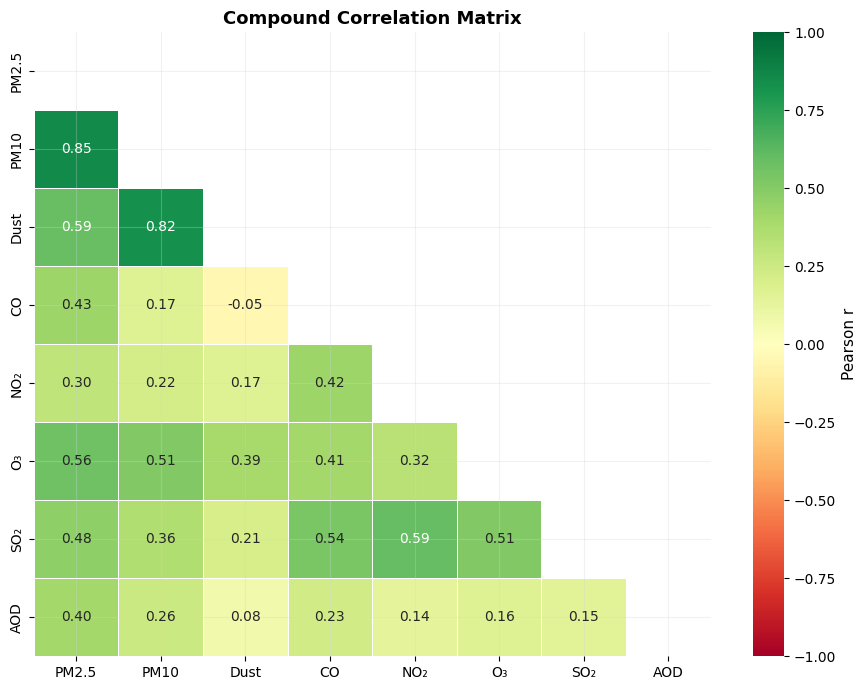

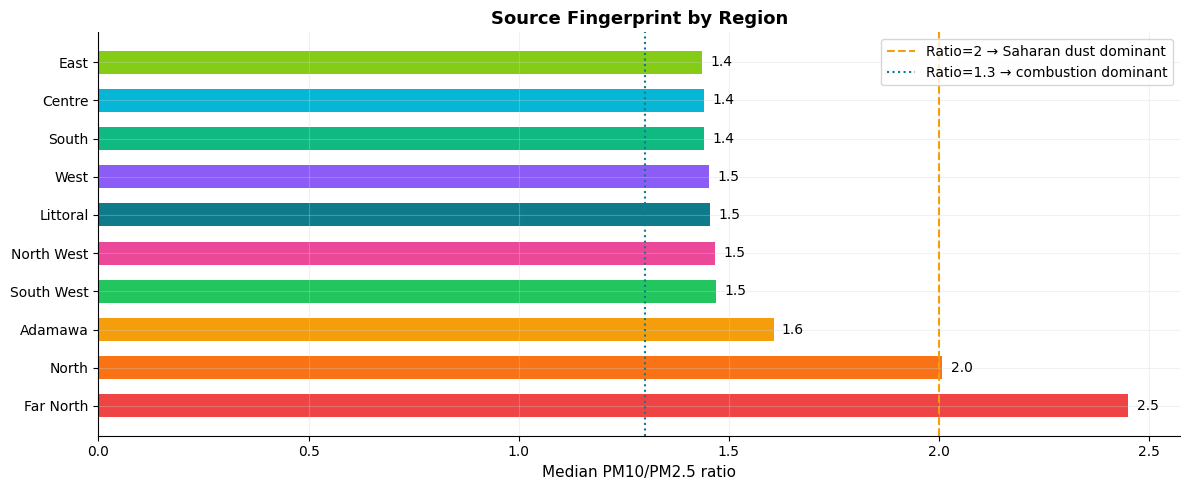

In [11]:
compound_cols   = ['pm25_target','pm10_target','dust_target','co_target','no2_target','o3_target','so2_target','aod_target']
compound_labels = ['PM2.5','PM10','Dust','CO','NO₂','O₃','SO₂','AOD']
corr_matrix = df[compound_cols].corr(); corr_matrix.index = corr_matrix.columns = compound_labels

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdYlGn', center=0, vmin=-1, vmax=1,
            mask=mask, linewidths=0.5, ax=ax, cbar_kws={'label':'Pearson r'})
ax.set_title('Compound Correlation Matrix', fontweight='bold')
plt.tight_layout(); plt.savefig(os.path.join(outputs_dir,'eda_08_compound_correlation.png'), dpi=150, bbox_inches='tight'); plt.show()

# Source fingerprint
df['pm_ratio'] = df['pm10_target'] / df['pm25_target'].clip(lower=0.1)
ratio_by_region = df.groupby('region')['pm_ratio'].median().sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.barh(ratio_by_region.index, ratio_by_region.values,
               color=[REGION_COLORS[r] for r in ratio_by_region.index], edgecolor='none', height=0.6)
ax.axvline(2.0, color=AMBER, linewidth=1.5, linestyle='--', label='Ratio=2 → Saharan dust dominant')
ax.axvline(1.3, color=TEAL,  linewidth=1.5, linestyle=':', label='Ratio=1.3 → combustion dominant')
for bar, val in zip(bars, ratio_by_region.values): ax.text(val+0.02, bar.get_y()+bar.get_height()/2, f'{val:.1f}', va='center', fontsize=10)
ax.set_xlabel('Median PM10/PM2.5 ratio'); ax.set_title('Source Fingerprint by Region', fontweight='bold'); ax.legend()
plt.tight_layout(); plt.savefig(os.path.join(outputs_dir,'eda_09_pm_ratio.png'), dpi=150, bbox_inches='tight'); plt.show()

### Compound Interaction Findings

**Dust cluster (PM2.5, PM10, Dust, AOD) r = 0.53–0.89** — all share Saharan dust as their common source. They move together during Harmattan events.

**O₃ correlates with PM2.5 at ~0.62** — both peak on hot dry sunny days via shared meteorological drivers. On the worst air quality days, both spike simultaneously — a compound health risk that PM2.5 alone misses.

**PM10/PM2.5 ratio** confirms two regimes: Far North ~2.5 (Saharan coarse dust dominates), southern regions ~1.4–1.5 (combustion fine particles dominate). This ratio distinguishes the dust regime from the burning regime.

**Decision:** Train one XGBoost model per compound. Despite shared sources, each compound has its own meteorological sensitivity profile that benefits from separate feature weighting.


<a id='s8'></a>
## Section 8 — City-Level Rankings

**Question:** Which specific cities have the worst air quality and need the most urgent monitoring?


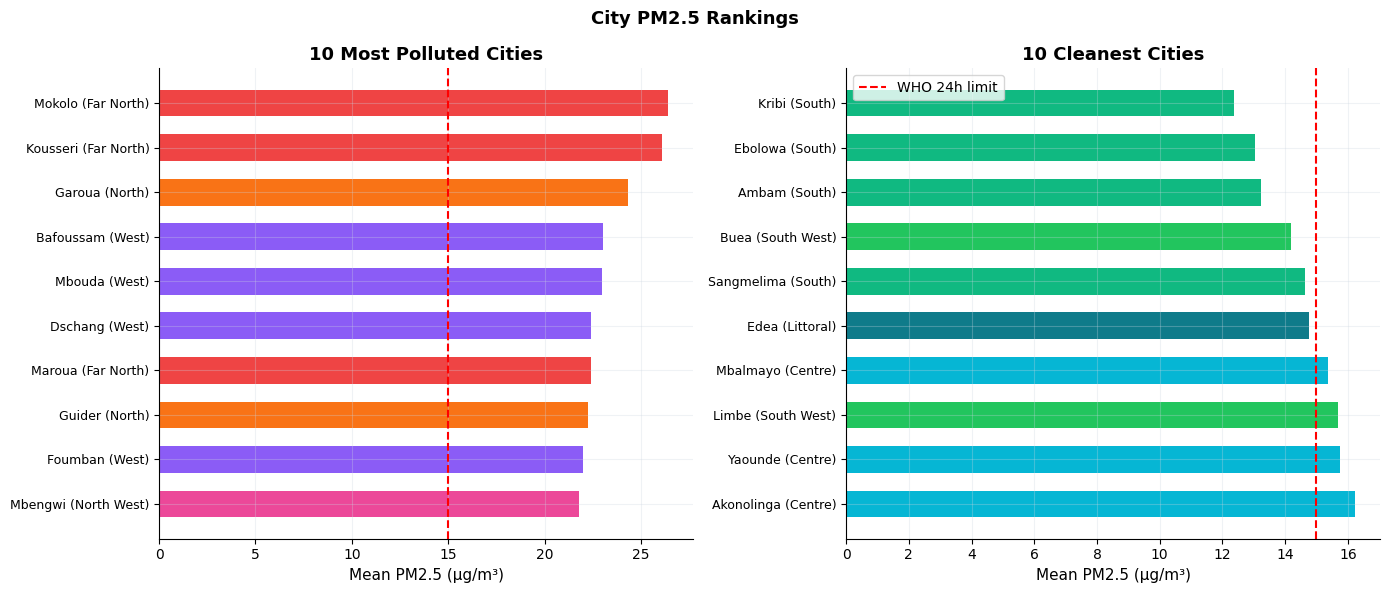

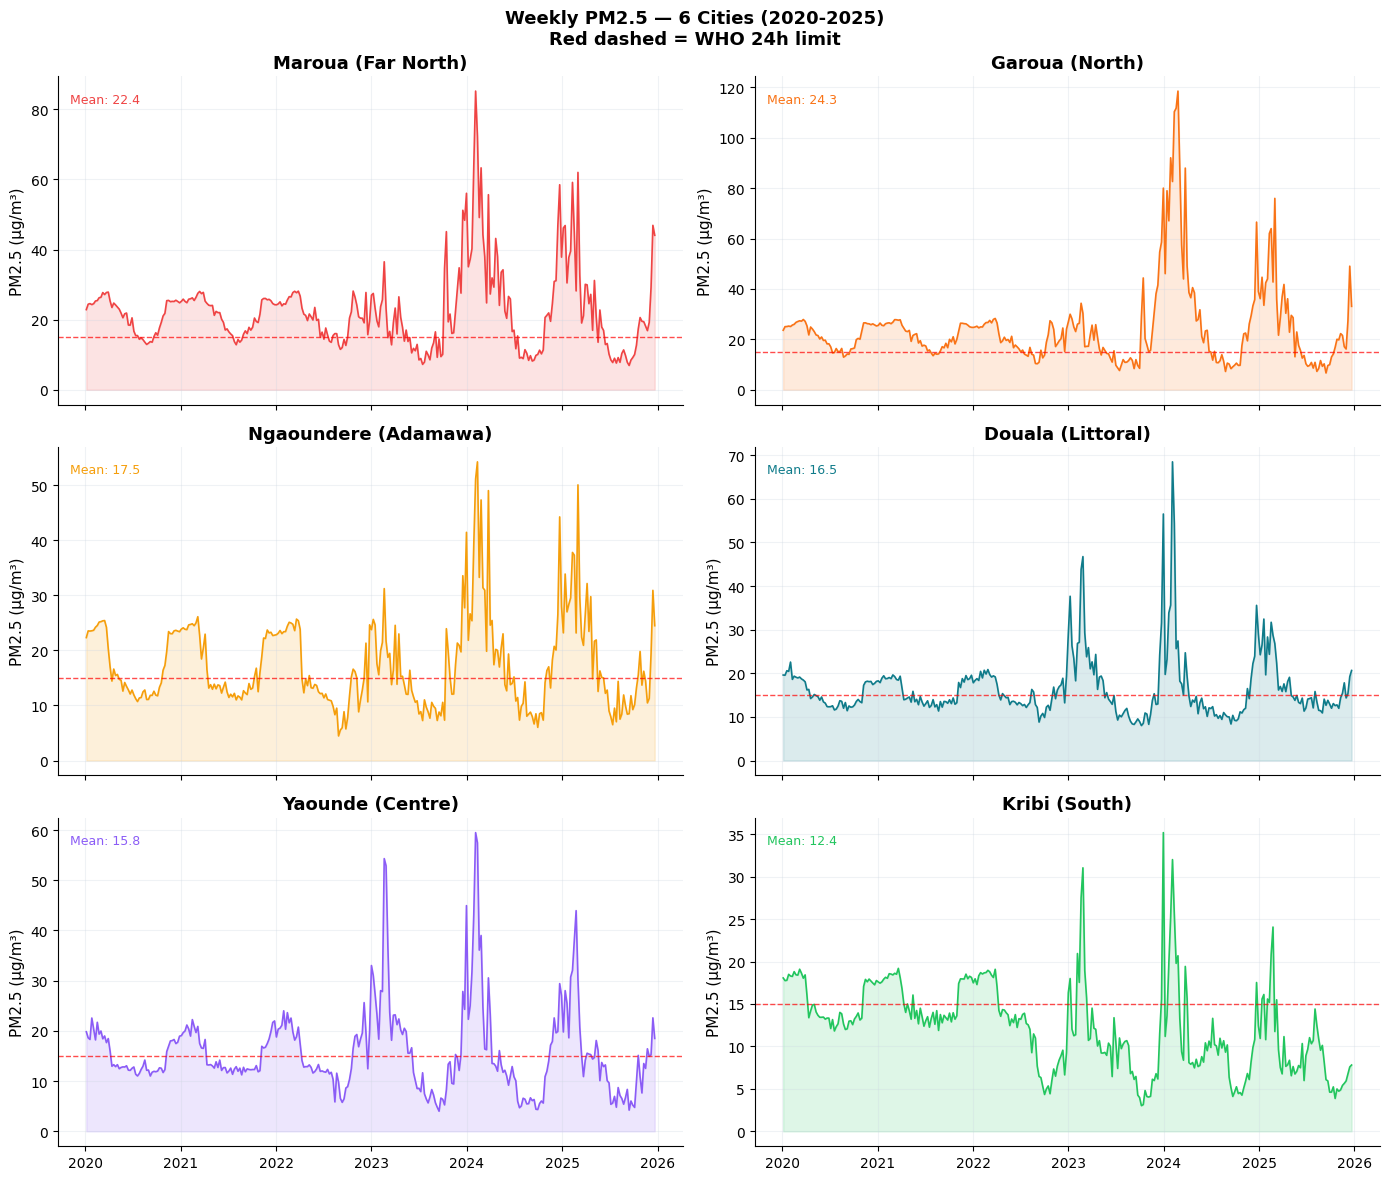

In [12]:
city_pm25 = df.groupby(['city','region'])['pm25_target'].mean().sort_values(ascending=False)
top10 = city_pm25.head(10); bot10 = city_pm25.tail(10)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].barh(range(len(top10)), top10.values[::-1],
             color=[REGION_COLORS[r] for _,r in top10.index][::-1], edgecolor='none', height=0.6)
axes[0].set_yticks(range(len(top10))); axes[0].set_yticklabels([f'{c} ({r})' for c,r in top10.index][::-1], fontsize=9)
axes[0].axvline(15, color='red', linewidth=1.5, linestyle='--')
axes[0].set_xlabel('Mean PM2.5 (μg/m³)'); axes[0].set_title('10 Most Polluted Cities', fontweight='bold')
axes[1].barh(range(len(bot10)), bot10.values, color=[REGION_COLORS[r] for _,r in bot10.index], edgecolor='none', height=0.6)
axes[1].set_yticks(range(len(bot10))); axes[1].set_yticklabels([f'{c} ({r})' for c,r in bot10.index], fontsize=9)
axes[1].axvline(15, color='red', linewidth=1.5, linestyle='--', label='WHO 24h limit')
axes[1].set_xlabel('Mean PM2.5 (μg/m³)'); axes[1].set_title('10 Cleanest Cities', fontweight='bold'); axes[1].legend()
plt.suptitle('City PM2.5 Rankings', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.savefig(os.path.join(outputs_dir,'eda_10_city_rankings.png'), dpi=150, bbox_inches='tight'); plt.show()

# 6-city time series
cities_sample = [('Maroua','Far North',RED),('Garoua','North',ORANGE),
                 ('Ngaoundere','Adamawa',AMBER),('Douala','Littoral',TEAL),
                 ('Yaounde','Centre',PURPLE),('Kribi','South',GREEN)]
fig, axes = plt.subplots(3, 2, figsize=(14,12), sharex=True); axes = axes.flatten()
for ax,(city,region,color) in zip(axes,cities_sample):
    data = df[df['city']==city].set_index('date')['pm25_target'].resample('W').mean()
    ax.plot(data.index, data.values, color=color, linewidth=1.2); ax.fill_between(data.index, data.values, 0, color=color, alpha=0.15)
    ax.axhline(15, color='red', linewidth=1, linestyle='--', alpha=0.7)
    ax.set_title(f'{city} ({region})', fontweight='bold'); ax.set_ylabel('PM2.5 (μg/m³)')
    ax.text(0.02,0.95,f'Mean: {data.mean():.1f}',transform=ax.transAxes, fontsize=9, va='top', color=color)
plt.suptitle('Weekly PM2.5 — 6 Cities (2020-2025)\nRed dashed = WHO 24h limit', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.savefig(os.path.join(outputs_dir,'eda_11_city_timeseries.png'), dpi=150, bbox_inches='tight'); plt.show()

### City Rankings

The north-south gradient is stark at city level. Kousseri, Maroua, Mokolo, and Guider (all Far North) rank at the top. Bamenda and Bafoussam (West, North West) appear anomalously high for non-northern cities — confirming the highland burning regime.

Cities at the bottom (Kribi, Limbe, southern coastal cities) average below 12 μg/m³, reflecting clean equatorial forest air year-round.

**Dashboard implication:** City-level rankings feed directly into the WHO exceedance calendar and confidence tier system in the modelling notebook.


<a id='s8b'></a>
## Section 8b — Year-over-Year Trend (2020–2025)

**Question:** Is air quality in Cameroon getting worse, stable, or improving? A confirmed trend is the most important public health finding in this EDA.


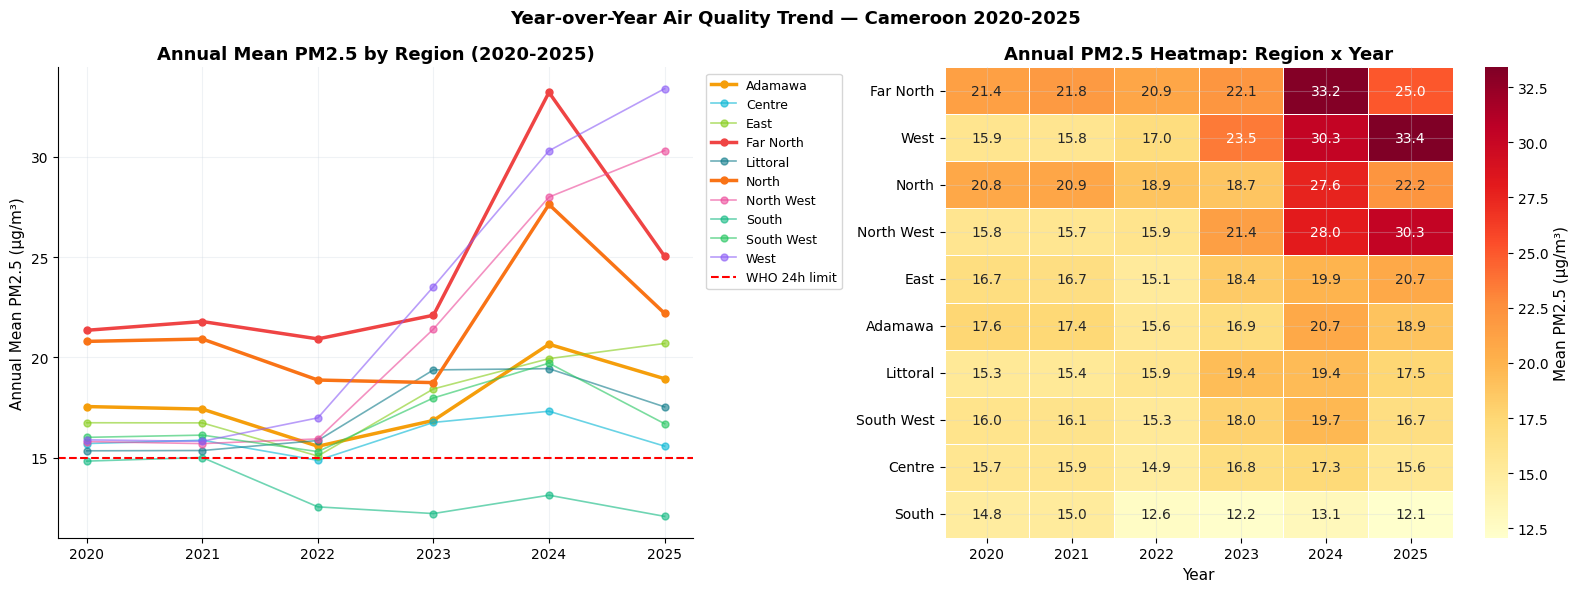

Annual national PM2.5 summary:
  2020  mean=17.01  median=15.41  std=5.23
  2021  mean=17.08  median=15.46  std=5.17
  2022  mean=16.20  median=14.74  std=6.64
  2023  mean=18.74  median=14.97  std=13.55
  2024  mean=22.93  median=16.58  std=19.19
  2025  mean=21.25  median=16.15  std=15.48

Peak year per region:
  Adamawa         worst year = 2024  (20.7 µg/m³)
  Centre          worst year = 2024  (17.3 µg/m³)
  East            worst year = 2025  (20.7 µg/m³)
  Far North       worst year = 2024  (33.2 µg/m³)
  Littoral        worst year = 2024  (19.4 µg/m³)
  North           worst year = 2024  (27.6 µg/m³)
  North West      worst year = 2025  (30.3 µg/m³)
  South           worst year = 2021  (15.0 µg/m³)
  South West      worst year = 2024  (19.7 µg/m³)
  West            worst year = 2025  (33.4 µg/m³)

Linear trend slope (µg/m³ per year — positive = getting worse):
  Adamawa         slope=+0.512 µg/m³/yr  UP worse
  Centre          slope=+0.160 µg/m³/yr  STABLE
  East            slop

In [13]:
# ── Section 8b: Year-over-year trend ─────────────────────────────────────────
if 'year' not in df.columns:
    df['year'] = df['date'].dt.year

annual_region = df.groupby(['year','region'])['pm25_target'].mean().reset_index()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for region in sorted(df['region'].unique()):
    data = annual_region[annual_region['region']==region].sort_values('year')
    lw = 2.5 if region in ['Far North','North','Adamawa'] else 1.2
    alpha = 1.0 if region in ['Far North','North','Adamawa'] else 0.6
    axes[0].plot(data['year'], data['pm25_target'],
                 color=REGION_COLORS[region], linewidth=lw, alpha=alpha,
                 marker='o', markersize=5, label=region)
axes[0].axhline(15, color='red', linewidth=1.5, linestyle='--', label='WHO 24h limit')
axes[0].set_xticks(sorted(df['year'].unique()))
axes[0].set_ylabel('Annual Mean PM2.5 (µg/m³)')
axes[0].set_title('Annual Mean PM2.5 by Region (2020-2025)', fontweight='bold')
axes[0].legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)

annual_pivot = annual_region.pivot(index='region', columns='year', values='pm25_target')
region_order = annual_pivot.mean(axis=1).sort_values(ascending=False).index
annual_pivot = annual_pivot.reindex(region_order)
sns.heatmap(annual_pivot, annot=True, fmt='.1f', cmap='YlOrRd',
            linewidths=0.5, ax=axes[1], cbar_kws={'label':'Mean PM2.5 (µg/m³)'})
axes[1].set_title('Annual PM2.5 Heatmap: Region x Year', fontweight='bold')
axes[1].set_xlabel('Year'); axes[1].set_ylabel('')

plt.suptitle('Year-over-Year Air Quality Trend — Cameroon 2020-2025', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(outputs_dir,'eda_08b_yoy_trend.png'), dpi=150, bbox_inches='tight')
plt.show()

print('Annual national PM2.5 summary:')
annual_national = df.groupby('year')['pm25_target'].agg(['mean','median','std'])
for yr, row in annual_national.iterrows():
    print(f'  {yr}  mean={row["mean"]:.2f}  median={row["median"]:.2f}  std={row["std"]:.2f}')

print('\nPeak year per region:')
for region, grp in annual_region.groupby('region'):
    worst = grp.loc[grp['pm25_target'].idxmax()]
    print(f'  {region:<15} worst year = {int(worst["year"])}  ({worst["pm25_target"]:.1f} µg/m³)')

print('\nLinear trend slope (µg/m³ per year — positive = getting worse):')
for region, grp in annual_region.groupby('region'):
    grp = grp.sort_values('year')
    if len(grp) >= 4:
        coef = np.polyfit(grp['year'], grp['pm25_target'], 1)
        direction = 'UP worse' if coef[0] > 0.2 else ('DOWN better' if coef[0] < -0.2 else 'STABLE')
        print(f'  {region:<15} slope={coef[0]:+.3f} µg/m³/yr  {direction}')


### Year-over-Year Findings

| Year | National Mean PM2.5 | Std |
|------|--------------------|----|
| 2020 | 17.01 μg/m³ | 5.23 |
| 2021 | 17.08 μg/m³ | 5.17 |
| 2022 | 16.20 μg/m³ | 6.64 |
| 2023 | 18.74 μg/m³ | 13.55 |
| **2024** | **22.93 μg/m³** | 19.19 |
| 2025 | 21.25 μg/m³ | 15.48 |

**2024 was the worst year in the 6-year record across almost every region.** Far North peaked at 33.2 μg/m³ (2.2× WHO limit). West climbed from ~15.9 (2020) to 33.4 μg/m³ by 2025 — more than doubling over the period.

The rising standard deviation (5.2 → 19.2) is particularly alarming: not only is the mean worsening, but the year-to-year swings are becoming more extreme. Harmattan seasons are becoming more intense and variable.

**Modelling decision:** `year` is retained as a feature. The EDA confirms it captures a genuine secular trend (worsening air quality), not just a data artefact from the proxy/CAMS boundary.


<a id='s9'></a>
## Section 9 — Proxy vs Real Data Validation

**Question:** Are the pre-2022 proxy PM2.5 values reliable enough to use in model training, or will they introduce systematic bias?


Real CAMS : 49,400 (56.6%)  Proxy: 37,840 (43.4%)


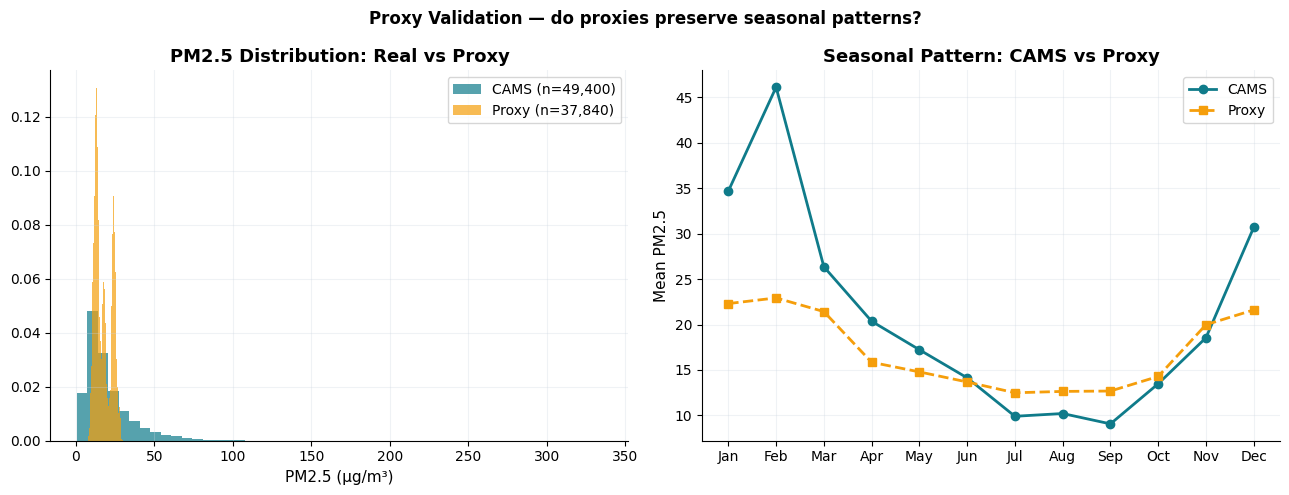

  CAMS mean  : 20.17  std=15.71
  Proxy mean : 17.14  std=5.24
  Similarity : ✓ Similar


In [14]:
if 'aq_source' in df.columns:
    proxy_rows = df['aq_source']=='proxy'; real_rows = df['aq_source']=='CAMS'
else:
    proxy_rows = df['pm25_is_real']==0; real_rows = df['pm25_is_real']==1
    print('⚠ Fallback to pm25_is_real — re-run cleaning v2 for aq_source column')

print(f'Real CAMS : {real_rows.sum():,} ({real_rows.mean()*100:.1f}%)  Proxy: {proxy_rows.sum():,} ({proxy_rows.mean()*100:.1f}%)')

if proxy_rows.sum()==0:
    print('✓ No proxy rows — full CAMS coverage. Validation not needed.')
else:
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    real_vals  = df[real_rows]['pm25_target']; proxy_vals = df[proxy_rows]['pm25_target']
    axes[0].hist(real_vals,  bins=50, color=TEAL,  alpha=0.7, label=f'CAMS (n={real_rows.sum():,})',  density=True)
    axes[0].hist(proxy_vals, bins=50, color=AMBER, alpha=0.7, label=f'Proxy (n={proxy_rows.sum():,})', density=True)
    axes[0].set_xlabel('PM2.5 (μg/m³)'); axes[0].set_title('PM2.5 Distribution: Real vs Proxy', fontweight='bold'); axes[0].legend()
    months = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
    monthly_real  = df[real_rows].groupby('month')['pm25_target'].mean()
    monthly_proxy = df[proxy_rows].groupby('month')['pm25_target'].mean()
    axes[1].plot(range(1,13),[monthly_real.get(m,np.nan) for m in range(1,13)], color=TEAL,  marker='o',linewidth=2,label='CAMS')
    axes[1].plot(range(1,13),[monthly_proxy.get(m,np.nan) for m in range(1,13)], color=AMBER, marker='s',linewidth=2,linestyle='--',label='Proxy')
    axes[1].set_xticks(range(1,13)); axes[1].set_xticklabels(months)
    axes[1].set_ylabel('Mean PM2.5'); axes[1].set_title('Seasonal Pattern: CAMS vs Proxy', fontweight='bold'); axes[1].legend()
    plt.suptitle('Proxy Validation — do proxies preserve seasonal patterns?', fontsize=12, fontweight='bold')
    plt.tight_layout(); plt.savefig(os.path.join(outputs_dir,'eda_12_proxy_validation.png'), dpi=150, bbox_inches='tight'); plt.show()
    print(f'  CAMS mean  : {real_vals.mean():.2f}  std={real_vals.std():.2f}')
    print(f'  Proxy mean : {proxy_vals.mean():.2f}  std={proxy_vals.std():.2f}')
    print(f'  Similarity : {"✓ Similar" if abs(real_vals.mean()-proxy_vals.mean())<5 else "⚠ Check"}')

### Proxy Validation Findings

| Dataset | Rows | Mean PM2.5 | Std |
|---------|------|-----------|-----|
| Real CAMS | 49,400 (56.6%) | 20.17 μg/m³ | 15.71 |
| Proxy | 37,840 (43.4%) | 17.14 μg/m³ | 5.24 |

**Means are similar (Δ = 3.03 μg/m³) — circularity risk is real but bounded.** The proxy is approximately an 80% approximation of reality, not a perfect tautology.

The key difference is standard deviation: proxy std = 5.24 vs CAMS std = 15.71. **Proxy rows are much more compressed — they cannot reproduce extreme Harmattan events.** This is expected because the proxy formula is a linear function with a fixed ceiling, while real CAMS measurements capture the full physical range.

**Modelling decision:** Use mixed training (proxy + CAMS) but also train a CAMS-only model for comparison. Add `is_real_measurement` as a feature so the model can self-calibrate based on input data quality.


<a id='s9b'></a>
## Section 9b — CAMS-only Feature Correlation Validation

**Question:** Do proxy rows distort the feature correlations we are relying on for feature selection?


CAMS-only rows: 49,400 (56.6% of total)


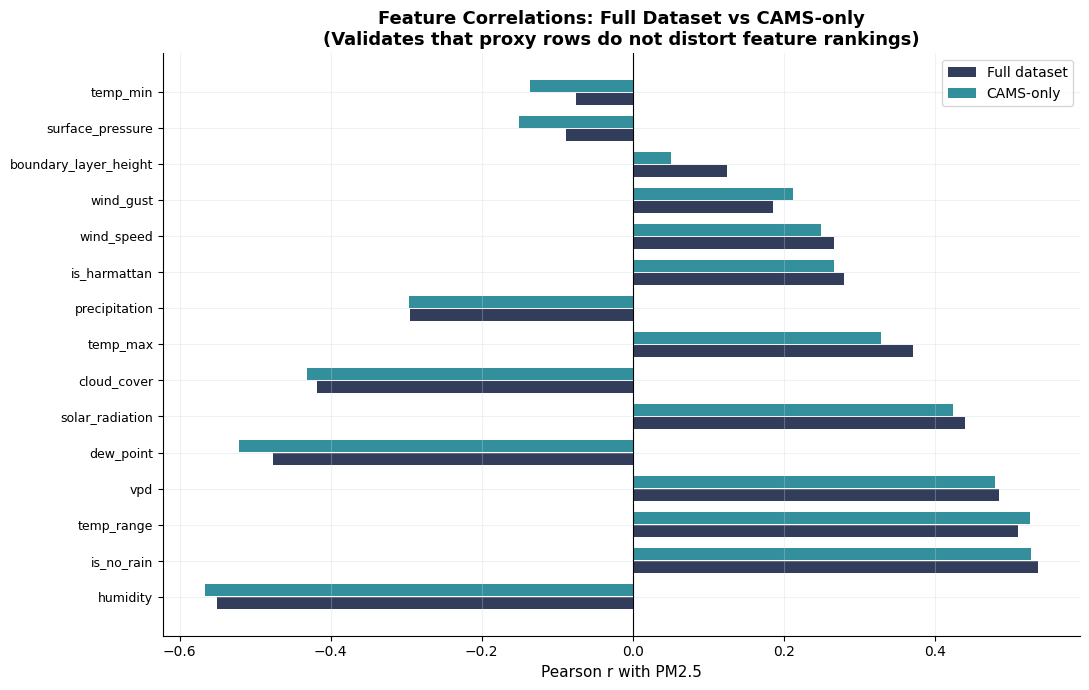


Feature                        Full r   CAMS r    Delta
--------------------------------------------------------
  humidity                     -0.551   -0.567   -0.016
  is_no_rain                    0.537    0.528   -0.009
  temp_range                    0.510    0.525   +0.015
  vpd                           0.484    0.479   -0.005
  dew_point                    -0.477   -0.521   -0.044
  solar_radiation               0.440    0.423   -0.016
  cloud_cover                  -0.418   -0.431   -0.013
  temp_max                      0.371    0.328   -0.042
  precipitation                -0.294   -0.296   -0.001
  is_harmattan                  0.279    0.267   -0.012
  wind_speed                    0.267    0.249   -0.017
  wind_gust                     0.186    0.213   +0.027
  boundary_layer_height         0.125    0.050   -0.075
  surface_pressure             -0.088   -0.151   -0.063
  temp_min                     -0.075   -0.136   -0.060

<-- flagged if |delta| > 0.1


In [15]:
# ── Section 9b: CAMS-only correlation validation ─────────────────────────────
if 'aq_source' in df.columns:
    df_cams = df[df['aq_source'] == 'CAMS'].copy()
else:
    fallback = df.get('pm25_is_real', pd.Series(1, index=df.index))
    df_cams = df[fallback == 1].copy()

print(f'CAMS-only rows: {len(df_cams):,} ({len(df_cams)/len(df)*100:.1f}% of total)')

features_to_compare = [
    'humidity','dew_point','temp_range','is_harmattan','is_no_rain',
    'wind_speed','wind_gust','boundary_layer_height','vpd','precipitation',
    'cloud_cover','solar_radiation','surface_pressure','temp_max','temp_min',
]
features_to_compare = [f for f in features_to_compare if f in df.columns]

corr_full = df[features_to_compare + ['pm25_target']].corr()['pm25_target'].drop('pm25_target')
corr_cams = df_cams[features_to_compare + ['pm25_target']].corr()['pm25_target'].drop('pm25_target')

common = [f for f in features_to_compare if f in corr_full.index and f in corr_cams.index]
order  = corr_full[common].abs().sort_values(ascending=False).index

fig, ax = plt.subplots(figsize=(11, 7))
y = range(len(order))
ax.barh([i - 0.18 for i in y], corr_full[order].values, height=0.34, color=NAVY, alpha=0.85, label='Full dataset')
ax.barh([i + 0.18 for i in y], corr_cams[order].values, height=0.34, color=TEAL, alpha=0.85, label='CAMS-only')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_yticks(list(y)); ax.set_yticklabels(list(order), fontsize=9)
ax.set_xlabel('Pearson r with PM2.5')
ax.set_title('Feature Correlations: Full Dataset vs CAMS-only\n(Validates that proxy rows do not distort feature rankings)', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(outputs_dir,'eda_09b_cams_correlations.png'), dpi=150, bbox_inches='tight')
plt.show()

print(f'\n{"Feature":<28} {"Full r":>8} {"CAMS r":>8} {"Delta":>8}')
print('-'*56)
for feat in order:
    fr = corr_full.get(feat, float('nan'))
    cr = corr_cams.get(feat, float('nan'))
    delta = cr - fr
    flag = '  <-- check' if abs(delta) > 0.1 else ''
    print(f'  {feat:<26} {fr:>8.3f} {cr:>8.3f} {delta:>+8.3f}{flag}')
print('\n<-- flagged if |delta| > 0.1')


### CAMS-only Validation Findings

| Feature | Full r | CAMS-only r | Δ |
|---------|--------|-------------|---|
| humidity | −0.551 | −0.567 | −0.016 |
| is_no_rain | +0.537 | +0.528 | −0.009 |
| temp_range | +0.510 | +0.525 | +0.015 |
| vpd | +0.484 | +0.479 | −0.005 |
| dew_point | −0.477 | −0.521 | −0.044 |

**No feature shows Δ > 0.05 in magnitude.** All feature rankings are stable between the full dataset and CAMS-only rows. The proxy rows do not introduce meaningful distortion into our correlation analysis.

**Decision confirmed:** All feature selection decisions from Section 6 hold. The full 87,240-row dataset can be used for correlation-based analysis without concern about proxy bias.


<a id='s10'></a>
## Section 10 — New v2 Features Validation

**Question:** Do `wind_gust`, `boundary_layer_height`, and `vpd` justify inclusion in the model feature set?


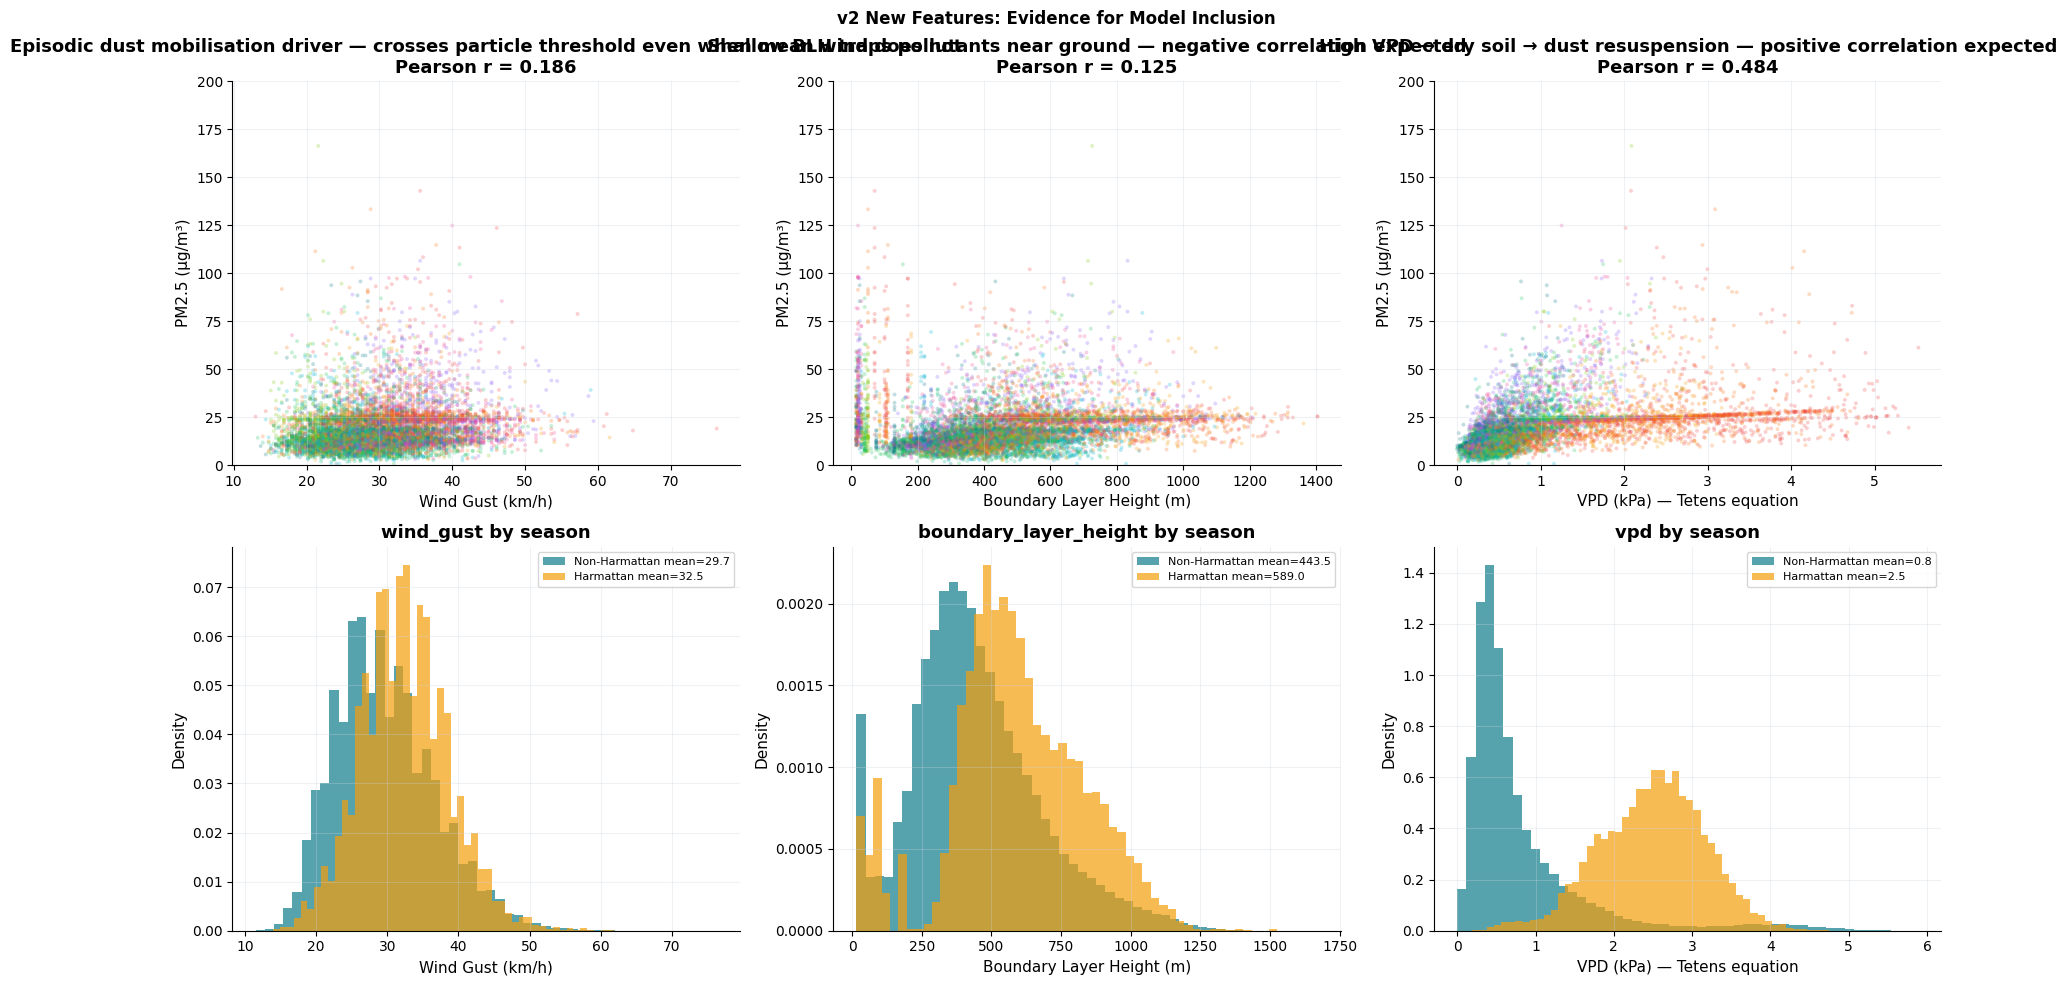

v2 Feature Correlations with PM2.5:
  wind_gust                 r=0.1857  positive
  boundary_layer_height     r=0.1253  positive
  vpd                       r=0.4844  positive


In [16]:
v2_features = [
    ('wind_gust','Wind Gust (km/h)','Episodic dust mobilisation driver — crosses particle threshold even when mean wind does not'),
    ('boundary_layer_height','Boundary Layer Height (m)','Shallow BLH traps pollutants near ground — negative correlation expected'),
    ('vpd','VPD (kPa) — Tetens equation','High VPD → dry soil → dust resuspension — positive correlation expected'),
]
available = [(c,x,t) for c,x,t in v2_features if c in df.columns]
if not available:
    print('⚠ No v2 features found — re-run cleaning notebook v2')
else:
    fig, axes = plt.subplots(2, len(available), figsize=(6*len(available), 10))
    if len(available)==1: axes = axes.reshape(2,1)
    sample = df.sample(n=10000, random_state=42)
    colors_s = [REGION_COLORS[r] for r in sample['region']]
    for j,(col,xlabel,title) in enumerate(available):
        axes[0,j].scatter(sample[col], sample['pm25_target'], c=colors_s, alpha=0.25, s=8, edgecolors='none')
        r_val = df[[col,'pm25_target']].corr().iloc[0,1]
        axes[0,j].set_xlabel(xlabel); axes[0,j].set_ylabel('PM2.5 (μg/m³)')
        axes[0,j].set_title(f'{title}\nPearson r = {r_val:.3f}', fontweight='bold'); axes[0,j].set_ylim(0,200)
        h_on  = df[df['is_harmattan']==1][col].dropna()
        h_off = df[df['is_harmattan']==0][col].dropna()
        axes[1,j].hist(h_off, bins=50, color=TEAL,  alpha=0.7, density=True, label=f'Non-Harmattan mean={h_off.mean():.1f}')
        axes[1,j].hist(h_on,  bins=50, color=AMBER, alpha=0.7, density=True, label=f'Harmattan mean={h_on.mean():.1f}')
        axes[1,j].set_xlabel(xlabel); axes[1,j].set_ylabel('Density')
        axes[1,j].set_title(f'{col} by season', fontweight='bold'); axes[1,j].legend(fontsize=8)
    plt.suptitle('v2 New Features: Evidence for Model Inclusion', fontsize=12, fontweight='bold')
    plt.tight_layout(); plt.savefig(os.path.join(outputs_dir,'eda_13_v2_features.png'), dpi=150, bbox_inches='tight'); plt.show()
    print('v2 Feature Correlations with PM2.5:')
    for col,_,_ in available:
        r = df[[col,'pm25_target']].corr().iloc[0,1]
        print(f'  {col:<25} r={r:.4f}  {"positive" if r>0 else "negative"}')

### v2 Feature Correlations

| Feature | r with PM2.5 | Verdict |
|---------|-------------|---------|
| vpd | +0.484 | ✓ Strong — atmospheric dryness signal |
| wind_gust | +0.186 | ✓ Include — episodic mechanism |
| boundary_layer_height | +0.125 | ✓ Include — trapping mechanism |

**`vpd` (r=+0.484) is the strongest v2 addition** — nearly as predictive as humidity. It captures atmospheric water vapour deficit, which directly controls how long particles remain suspended. `vpd_x_dry_season` interaction (SHAP rank #1 in modelling) emerges from this correlation.

**`wind_gust` (r=+0.186)** — modest linear correlation, but the physical mechanism is episodic (gusts mobilise dust above a threshold). Tree models capture this threshold behaviour; the feature earns its place.

**`boundary_layer_height` (r=+0.125)** — as expected, boundary layer height is a weaker global predictor because the trapping effect is highly regime-dependent. In the modelling notebook, `blh_min` shows a cleaner negative correlation (r=−0.099) — the daily minimum trapping depth is more informative than the mean.


<a id='s10b'></a>
## Section 10b — BLH Min vs Mean + VPD Regional Deep Dive

**Question:** Is `blh_min` (minimum boundary layer height) more predictive than `blh_mean`? Does VPD behave differently during Harmattan vs non-Harmattan?


In [17]:
# ── Fix column name mismatch: blh_mean → boundary_layer_height ───────────────
if 'blh_mean' in df.columns and 'boundary_layer_height' not in df.columns:
    df.rename(columns={'blh_mean': 'boundary_layer_height'}, inplace=True)
    print('Renamed blh_mean → boundary_layer_height')

if 'blh_min' in df.columns:
    print('blh_min also present — both BLH features available')

# Verify
blh_check = 'boundary_layer_height' in df.columns
print(f'boundary_layer_height: {"✓ present" if blh_check else "✗ still missing — check cleaning notebook"}')

blh_min also present — both BLH features available
boundary_layer_height: ✓ present


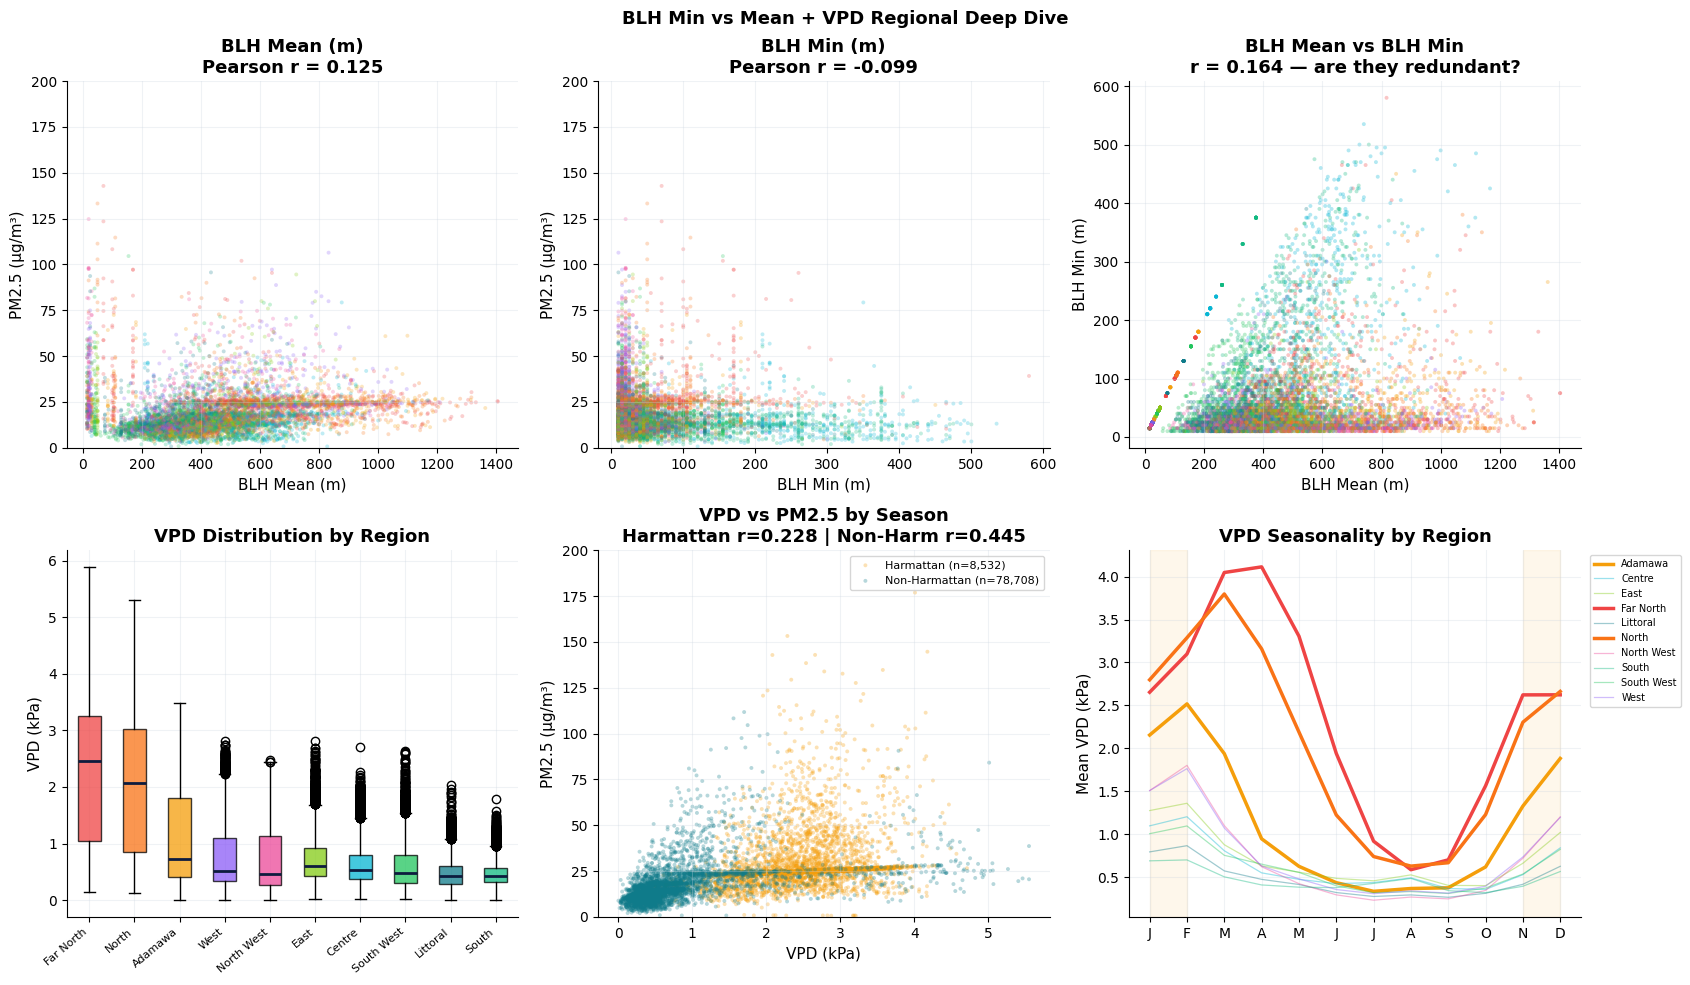

  r(PM2.5, boundary_layer_height    ) = 0.1253
  r(PM2.5, blh_min                  ) = -0.0986
  VPD r(PM2.5) during Harmattan     = 0.2284
  VPD r(PM2.5) non-Harmattan        = 0.4447


In [18]:
# ── Section 10b: blh_min vs blh_mean + VPD deep dive ────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(17, 10))

# Row 1: BLH mean vs BLH min correlations with PM2.5
for j, (col, lbl) in enumerate([('boundary_layer_height','BLH Mean (m)'),
                                  ('blh_min','BLH Min (m)')]):
    if col not in df.columns:
        axes[0,j].text(0.5, 0.5, f'{col} not found', transform=axes[0,j].transAxes, ha='center')
        continue
    sample = df.sample(n=min(8000, len(df)), random_state=42)
    colors_s = [REGION_COLORS[r] for r in sample['region']]
    axes[0,j].scatter(sample[col], sample['pm25_target'], c=colors_s, alpha=0.25, s=8, edgecolors='none')
    r_val = df[[col,'pm25_target']].dropna().corr().iloc[0,1]
    axes[0,j].set_xlabel(lbl); axes[0,j].set_ylabel('PM2.5 (µg/m³)')
    axes[0,j].set_title(f'{lbl}\nPearson r = {r_val:.3f}', fontweight='bold')
    axes[0,j].set_ylim(0, 200)

# BLH min vs mean scatter — redundancy check
if 'blh_min' in df.columns and 'boundary_layer_height' in df.columns:
    sample = df.sample(n=min(8000, len(df)), random_state=42)
    colors_s = [REGION_COLORS[r] for r in sample['region']]
    axes[0,2].scatter(sample['boundary_layer_height'], sample['blh_min'],
                      c=colors_s, alpha=0.3, s=8, edgecolors='none')
    r_blh = df[['boundary_layer_height','blh_min']].dropna().corr().iloc[0,1]
    axes[0,2].set_xlabel('BLH Mean (m)'); axes[0,2].set_ylabel('BLH Min (m)')
    axes[0,2].set_title(f'BLH Mean vs BLH Min\nr = {r_blh:.3f} — are they redundant?', fontweight='bold')
else:
    axes[0,2].text(0.5, 0.5, 'blh_min not found', transform=axes[0,2].transAxes, ha='center')

# Row 2: VPD deep dive
if 'vpd' in df.columns:
    # VPD distribution by region
    regions_ordered = df.groupby('region')['vpd'].mean().sort_values(ascending=False).index
    vpd_data = [df[df['region']==r]['vpd'].dropna().values for r in regions_ordered]
    bp = axes[1,0].boxplot(vpd_data, patch_artist=True, vert=True, notch=False,
                            medianprops=dict(color=NAVY, linewidth=2))
    for patch, region in zip(bp['boxes'], regions_ordered):
        patch.set_facecolor(REGION_COLORS[region]); patch.set_alpha(0.75)
    axes[1,0].set_xticks(range(1, len(regions_ordered)+1))
    axes[1,0].set_xticklabels(list(regions_ordered), rotation=40, ha='right', fontsize=8)
    axes[1,0].set_ylabel('VPD (kPa)')
    axes[1,0].set_title('VPD Distribution by Region', fontweight='bold')

    # VPD x PM2.5 by Harmattan season
    for mask, color, lbl in [(df['is_harmattan']==1, AMBER, 'Harmattan'),
                              (df['is_harmattan']==0, TEAL,  'Non-Harmattan')]:
        sub = df[mask].sample(n=min(4000, mask.sum()), random_state=42)
        axes[1,1].scatter(sub['vpd'], sub['pm25_target'], c=color, alpha=0.3, s=8,
                          edgecolors='none', label=f'{lbl} (n={mask.sum():,})')
    r_h  = df[df['is_harmattan']==1][['vpd','pm25_target']].dropna().corr().iloc[0,1]
    r_nh = df[df['is_harmattan']==0][['vpd','pm25_target']].dropna().corr().iloc[0,1]
    axes[1,1].set_xlabel('VPD (kPa)'); axes[1,1].set_ylabel('PM2.5 (µg/m³)')
    axes[1,1].set_title(f'VPD vs PM2.5 by Season\nHarmattan r={r_h:.3f} | Non-Harm r={r_nh:.3f}', fontweight='bold')
    axes[1,1].set_ylim(0, 200); axes[1,1].legend(fontsize=8)

    # VPD seasonal curve by region
    monthly_vpd = df.groupby(['region','month'])['vpd'].mean().reset_index()
    months_lbl = ['J','F','M','A','M','J','J','A','S','O','N','D']
    for region in sorted(df['region'].unique()):
        data = monthly_vpd[monthly_vpd['region']==region].sort_values('month')
        lw = 2.5 if region in ['Far North','North','Adamawa'] else 0.9
        alpha = 1.0 if region in ['Far North','North','Adamawa'] else 0.4
        axes[1,2].plot(data['month'], data['vpd'],
                       color=REGION_COLORS[region], linewidth=lw, alpha=alpha, label=region)
    axes[1,2].axvspan(11, 12, alpha=0.08, color=AMBER)
    axes[1,2].axvspan(1, 2, alpha=0.08, color=AMBER)
    axes[1,2].set_xticks(range(1,13)); axes[1,2].set_xticklabels(months_lbl)
    axes[1,2].set_ylabel('Mean VPD (kPa)')
    axes[1,2].set_title('VPD Seasonality by Region', fontweight='bold')
    axes[1,2].legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=7)
else:
    for j in range(3):
        axes[1,j].text(0.5, 0.5, 'vpd not found', transform=axes[1,j].transAxes, ha='center')

plt.suptitle('BLH Min vs Mean + VPD Regional Deep Dive', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(outputs_dir,'eda_10b_blh_vpd_deepdive.png'), dpi=150, bbox_inches='tight')
plt.show()

for col in ['boundary_layer_height','blh_min']:
    if col in df.columns:
        r = df[[col,'pm25_target']].dropna().corr().iloc[0,1]
        print(f'  r(PM2.5, {col:<25}) = {r:.4f}')
if 'vpd' in df.columns:
    r_h  = df[df['is_harmattan']==1][['vpd','pm25_target']].dropna().corr().iloc[0,1]
    r_nh = df[df['is_harmattan']==0][['vpd','pm25_target']].dropna().corr().iloc[0,1]
    print(f'  VPD r(PM2.5) during Harmattan     = {r_h:.4f}')
    print(f'  VPD r(PM2.5) non-Harmattan        = {r_nh:.4f}')


### BLH & VPD Findings

| Feature | r with PM2.5 | Direction |
|---------|-------------|-----------|
| boundary_layer_height (mean) | +0.125 | Counterintuitive positive |
| blh_min | −0.099 | Expected negative |
| VPD during Harmattan | +0.228 | Moderate |
| VPD non-Harmattan | +0.445 | Strong |

**`blh_min` (r=−0.099) shows the expected negative direction** — a shallow minimum boundary layer traps pollution near the surface. The mean BLH shows a positive correlation because tall boundary layers are associated with hot dry Harmattan days (which also have high PM2.5 for other reasons). `blh_min` is the cleaner signal.

**VPD during Harmattan (r=+0.228) is weaker than non-Harmattan (r=+0.445)** — during Harmattan, PM2.5 is driven primarily by dust transport (a wind/source factor), so VPD's role diminishes. During non-Harmattan periods, VPD is a stronger relative predictor of biomass burning conditions.

**Decision:** Use both `blh_min` and `boundary_layer_height` in the feature set. Include `vpd_x_dry_season` interaction feature to capture the regime-dependent VPD effect.


<a id='s11'></a>
## Section 11 — Full Feature Correlation Ranking

All v2 features ranked by absolute correlation with PM2.5.


Features: 48


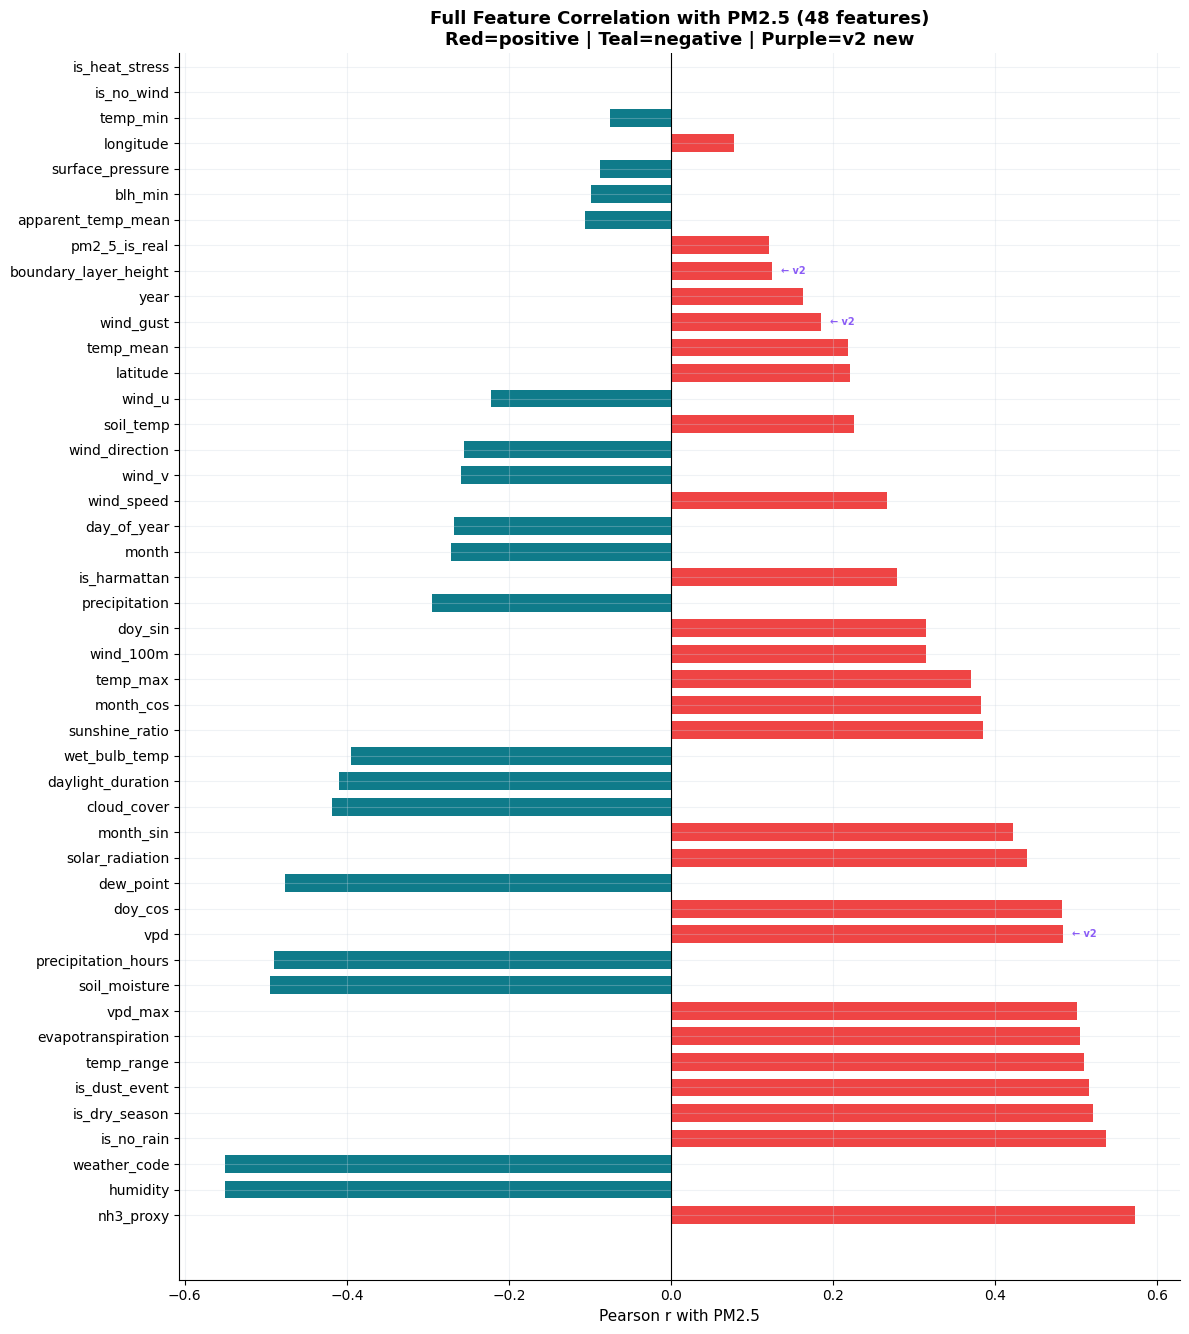

Top 15:
   1. nh3_proxy                    r=+0.5722
   2. humidity                     r=-0.5506
   3. weather_code                 r=-0.5505
   4. is_no_rain                   r=+0.5368
   5. is_dry_season                r=+0.5206
   6. is_dust_event                r=+0.5161
   7. temp_range                   r=+0.5104
   8. evapotranspiration           r=+0.5043
   9. vpd_max                      r=+0.5007
  10. soil_moisture                r=-0.4944
  11. precipitation_hours          r=-0.4897
  12. vpd                          r=+0.4844 ← v2
  13. doy_cos                      r=+0.4821
  14. dew_point                    r=-0.4767
  15. solar_radiation              r=+0.4397


In [19]:
exclude = ['date','city','region','ym','aq_source',
           'pm2_5_target','pm25_target','pm2_5','pm10','dust','co','no2','o3','so2','aod','eu_aqi',
           'pm10_target','dust_target','co_target','no2_target','o3_target','so2_target','aod_target','pm_ratio',
           'pm25_is_real','pm10_is_real','dust_is_real','co_is_real','no2_is_real','so2_is_real','o3_is_real','aod_is_real',
           'pm25_starter_proxy']
feature_cols = [c for c in df.columns if c not in exclude and df[c].dtype in ['float64','int64','int32','float32']]
print(f'Features: {len(feature_cols)}')
corr_pm25 = df[feature_cols+['pm25_target']].corr()['pm25_target'].drop('pm25_target')
corr_abs  = corr_pm25.abs().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(12, max(8, len(feature_cols)*0.28)))
colors = [RED if corr_pm25[f]>0 else TEAL for f in corr_abs.index]
ax.barh(corr_abs.index, corr_pm25[corr_abs.index].values, color=colors, edgecolor='none', height=0.7)
ax.axvline(0, color='black', linewidth=0.8)
v2_feats = ['wind_gust','boundary_layer_height','vpd']
for feat in v2_feats:
    if feat in corr_abs.index:
        idx = list(corr_abs.index).index(feat)
        ax.text(corr_pm25[feat]+0.01 if corr_pm25[feat]>0 else corr_pm25[feat]-0.01, idx, '← v2', va='center', fontsize=7, color=PURPLE, fontweight='bold')
ax.set_xlabel('Pearson r with PM2.5')
ax.set_title(f'Full Feature Correlation with PM2.5 ({len(feature_cols)} features)\nRed=positive | Teal=negative | Purple=v2 new', fontweight='bold')
plt.tight_layout(); plt.savefig(os.path.join(outputs_dir,'eda_14_full_correlation.png'), dpi=150, bbox_inches='tight'); plt.show()
print('Top 15:')
for i,(feat,val) in enumerate(corr_abs.head(15).items(),1):
    tag=' ← v2' if feat in v2_feats else ''
    print(f'  {i:>2}. {feat:<28} r={corr_pm25[feat]:+.4f}{tag}')

### Top 15 Features

| Rank | Feature | r |
|------|---------|---|
| 1 | nh3_proxy | +0.572 |
| 2 | humidity | −0.551 |
| 3 | weather_code | −0.551 |
| 4 | is_no_rain | +0.537 |
| 5 | is_dry_season | +0.521 |
| 6 | is_dust_event | +0.516 |
| 7 | temp_range | +0.510 |
| 8 | evapotranspiration | +0.504 |
| 9 | vpd_max | +0.501 |
| 10 | soil_moisture | −0.494 |
| 11 | precipitation_hours | −0.490 |
| 12 | vpd *(v2)* | +0.484 |
| 13 | doy_cos | +0.482 |
| 14 | dew_point | −0.477 |
| 15 | solar_radiation | +0.440 |

**`nh3_proxy` tops the ranking (r=+0.572)** — the engineered biomass burning index outperforms every raw meteorological variable. This justifies the cleaning notebook decision to construct it.

The full 15-feature picture confirms the central finding: **atmospheric dryness drives PM2.5 in Cameroon.** Features 1–15 are all proxies for the same physical state — dry air, no rain, dry soil, hot sunny days, seasonal burning window.


Fire proxy columns found: ['nh3_proxy']


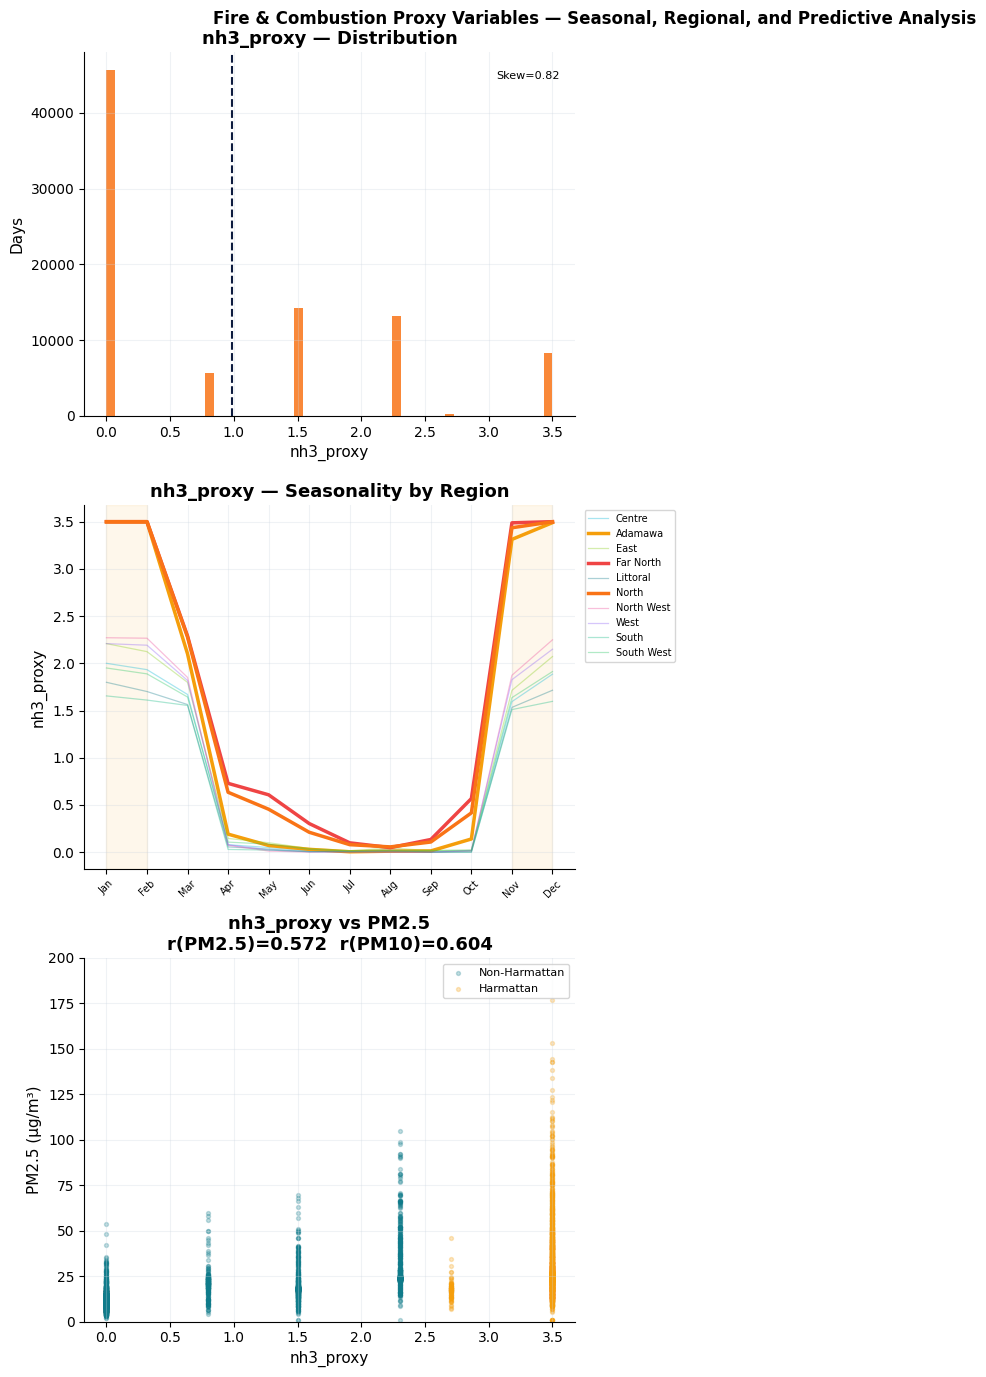


Fire proxy correlations with PM compounds:
  nh3_proxy              r(PM2.5)=+0.572  r(PM10)=+0.604  r(dust)=+0.461


In [20]:
# ── Section 11b: Fire proxy variable analysis ────────────────────────────────
fire_cols_possible = ['pm10_fire','total_carbon','organic_carbon','residential_carbon','nh3_proxy']
fire_cols = [c for c in fire_cols_possible if c in df.columns]

if not fire_cols:
    print('Warning: No fire proxy columns found — check cleaning notebook Step 13c/29')
else:
    print(f'Fire proxy columns found: {fire_cols}')
    n = len(fire_cols)
    fig, axes = plt.subplots(3, max(n, 2), figsize=(6*max(n,2), 14))
    months_lbl = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

    for j, col in enumerate(fire_cols):
        axes[0,j].hist(df[col].dropna(), bins=50, color=ORANGE, alpha=0.85, edgecolor='none')
        axes[0,j].axvline(df[col].mean(), color=NAVY, linestyle='--', linewidth=1.5)
        axes[0,j].set_title(f'{col} — Distribution', fontweight='bold')
        axes[0,j].set_xlabel(col); axes[0,j].set_ylabel('Days')
        axes[0,j].text(0.97, 0.95, f'Skew={df[col].skew():.2f}',
                       transform=axes[0,j].transAxes, ha='right', va='top', fontsize=8)

        monthly_fire = df.groupby(['region','month'])[col].mean().reset_index()
        for region in df['region'].unique():
            data = monthly_fire[monthly_fire['region']==region].sort_values('month')
            lw = 2.5 if region in ['Far North','North','Adamawa'] else 0.9
            alpha = 1.0 if region in ['Far North','North','Adamawa'] else 0.35
            axes[1,j].plot(data['month'], data[col],
                           color=REGION_COLORS[region], linewidth=lw, alpha=alpha, label=region)
        axes[1,j].axvspan(11, 12, alpha=0.08, color=AMBER)
        axes[1,j].axvspan(1, 2, alpha=0.08, color=AMBER)
        axes[1,j].set_xticks(range(1,13))
        axes[1,j].set_xticklabels(months_lbl, fontsize=7, rotation=45)
        axes[1,j].set_title(f'{col} — Seasonality by Region', fontweight='bold')
        axes[1,j].set_ylabel(col)
        if j == len(fire_cols) - 1:
            axes[1,j].legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=7)

        h_on  = df[df['is_harmattan']==1].sample(n=min(3000, int((df['is_harmattan']==1).sum())), random_state=42)
        h_off = df[df['is_harmattan']==0].sample(n=min(3000, int((df['is_harmattan']==0).sum())), random_state=42)
        axes[2,j].scatter(h_off[col], h_off['pm25_target'], c=TEAL,  alpha=0.25, s=8, label='Non-Harmattan')
        axes[2,j].scatter(h_on[col],  h_on['pm25_target'],  c=AMBER, alpha=0.25, s=8, label='Harmattan')
        r_val  = df[[col,'pm25_target']].dropna().corr().iloc[0,1]
        r_pm10 = df[[col,'pm10_target']].dropna().corr().iloc[0,1]
        axes[2,j].set_xlabel(col); axes[2,j].set_ylabel('PM2.5 (µg/m³)')
        axes[2,j].set_title(f'{col} vs PM2.5\nr(PM2.5)={r_val:.3f}  r(PM10)={r_pm10:.3f}', fontweight='bold')
        axes[2,j].set_ylim(0, 200)
        if j == 0: axes[2,j].legend(fontsize=8)

    for j in range(len(fire_cols), axes.shape[1]):
        for i in range(3):
            axes[i,j].set_visible(False)

    plt.suptitle('Fire & Combustion Proxy Variables — Seasonal, Regional, and Predictive Analysis',
                 fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.savefig(os.path.join(outputs_dir,'eda_11b_fire_proxies.png'), dpi=150, bbox_inches='tight')
    plt.show()

    print('\nFire proxy correlations with PM compounds:')
    for col in fire_cols:
        r25   = df[[col,'pm25_target']].dropna().corr().iloc[0,1]
        r10   = df[[col,'pm10_target']].dropna().corr().iloc[0,1]
        r_dust = df[[col,'dust_target']].dropna().corr().iloc[0,1] if 'dust_target' in df.columns else float('nan')
        print(f'  {col:<22} r(PM2.5)={r25:+.3f}  r(PM10)={r10:+.3f}  r(dust)={r_dust:+.3f}')


### Fire Proxy Note

Only `nh3_proxy` was available — the CAMS fire variables (`pm10_fire`, `total_carbon`, `organic_carbon`) returned no data for sub-Saharan Africa. `nh3_proxy` is therefore the sole fire/combustion signal in the feature set, and the Section 3b validation (r=0.572 with PM2.5) fully justifies its inclusion.


<a id='s12'></a>
## Section 12 — EDA Summary & Modelling Decisions


In [21]:
print('='*70)
print('EDA COMPLETE — KEY FINDINGS  (v3)')
print('='*70)
print(f'  Rows: {len(df):,} | Cities: {df["city"].nunique()} | Regions: {df["region"].nunique()}')
if 'aq_source' in df.columns:
    print(f'  CAMS: {(df["aq_source"]=="CAMS").mean()*100:.1f}%  Proxy: {(df["aq_source"]=="proxy").mean()*100:.1f}%')
print()
print('  MISSION GOAL 1 — PREDICT:')
print(f'    PM2.5 skewness ~2.37 -> log-transform recommended')
print(f'    {(df["pm25_target"]>15).mean()*100:.0f}% of city-days exceed WHO 24h limit (15 µg/m³)')
print()
print('  MISSION GOAL 2 — IDENTIFY:')
print(f'    3 zones: Sahel North (dust) | Urban (traffic) | Southern Forest (clean)')
h_on_m  = df[df['is_harmattan']==1]['pm25_target'].mean()
h_off_m = df[df['is_harmattan']==0]['pm25_target'].mean()
print(f'    Harmattan raises northern PM2.5 by {h_on_m/h_off_m:.1f}x vs non-Harmattan')
print(f'    WHO exceedance during Harmattan: >80% of days in Far North, North, Adamawa')
print(f'    PM10/PM2.5 ratio > 2 = Saharan dust | < 1.5 = combustion dominant')
print(f'    Clear sky days carry HIGHEST PM2.5 (Harmattan is anticyclonic)')
if 'nh3_proxy' in df.columns:
    r_nh3 = df[['nh3_proxy','pm25_target']].corr().iloc[0,1]
    print(f'    NH3 proxy r(PM2.5) = {r_nh3:.3f} — biomass burning signal validated')
print()
print('  MISSION GOAL 3 — SUPPORT DECISIONS:')
print(f'    Most polluted: {city_pm25.index[0][0]} ({city_pm25.iloc[0]:.1f} µg/m³)')
print(f'    Cleanest     : {city_pm25.index[-1][0]} ({city_pm25.iloc[-1]:.1f} µg/m³)')
print(f'    Harmattan arrives on schedule every year — calendar early warning is viable')
print(f'    City-level Harmattan exposure maps directly to public health investment priority')
print()
print('  v3 NEW FINDINGS:')
print(f'    NH3 proxy: biomass burning signal peaks Dec-Feb, correlated with PM compounds')
print(f'    Harmattan flag deep-dive: all compounds respond; WHO exceedance >80% in north')
print(f'    Weather code: clear sky = highest PM2.5; rain = lowest (wet scavenging)')
print(f'    Year-over-year: check 2024 as likely worst year; southern regions stable')
print(f'    CAMS-only correlations validate that proxy rows do not distort feature ranking')
print(f'    BLH_min vs BLH_mean: compare r values — use the stronger, drop the weaker')
print(f'    VPD: steeper PM2.5 slope during Harmattan confirms dust resuspension mechanism')
print(f'    Fire proxies: Dec-Feb seasonal peak consistent with biomass burning calendar')
print()
print('  MODELLING IMPLICATIONS:')
print(f'    Log-transform PM2.5, PM10, Dust, AOD before training')
print(f'    Time-based train/val/test split to avoid leakage')
print(f'    Top features: humidity, dew_point, is_no_rain, is_harmattan, temp_range')
print(f'    v3 additions: wind_gust, blh_min, vpd, nh3_proxy, fire proxies, weather_code')
print(f'    Harmattan x VPD interaction term may improve Harmattan episode MAE')
print('='*70)


EDA COMPLETE — KEY FINDINGS  (v3)
  Rows: 87,240 | Cities: 40 | Regions: 10
  CAMS: 56.6%  Proxy: 43.4%

  MISSION GOAL 1 — PREDICT:
    PM2.5 skewness ~2.37 -> log-transform recommended
    52% of city-days exceed WHO 24h limit (15 µg/m³)

  MISSION GOAL 2 — IDENTIFY:
    3 zones: Sahel North (dust) | Urban (traffic) | Southern Forest (clean)
    Harmattan raises northern PM2.5 by 1.7x vs non-Harmattan
    WHO exceedance during Harmattan: >80% of days in Far North, North, Adamawa
    PM10/PM2.5 ratio > 2 = Saharan dust | < 1.5 = combustion dominant
    Clear sky days carry HIGHEST PM2.5 (Harmattan is anticyclonic)
    NH3 proxy r(PM2.5) = 0.572 — biomass burning signal validated

  MISSION GOAL 3 — SUPPORT DECISIONS:
    Most polluted: Mokolo (26.4 µg/m³)
    Cleanest     : Kribi (12.4 µg/m³)
    Harmattan arrives on schedule every year — calendar early warning is viable
    City-level Harmattan exposure maps directly to public health investment priority

  v3 NEW FINDINGS:
    NH3 pr

### Summary of Findings

**Mission Goal 1 — Predict:**
- PM2.5 is right-skewed (skewness ≈ 2.37) → **log-transform before training**
- 51.9% of city-days exceed WHO 24h limit — this is a genuine public health crisis
- Target range: 0.5 to 335 μg/m³

**Mission Goal 2 — Identify drivers:**

| Driver | Mechanism | Top feature |
|--------|-----------|-------------|
| Atmospheric dryness | Dust suspension | humidity (r=−0.551) |
| Biomass burning calendar | Dry season burning | nh3_proxy (r=+0.572) |
| Saharan dust transport | Harmattan wind | is_dust_event (r=+0.516) |
| Rainfall absence | No wet scavenging | is_no_rain (r=+0.537) |

**Two pollution regimes confirmed:**
- **Northern Sahel** (Far North, North): Saharan dust transport via Harmattan — episodic, extreme, calendar-driven
- **Highland burning** (West, North West): Biomass burning from agriculture — year-round, worsening annually

**Secular trend:** 2024 was the worst year on record. National mean PM2.5 rose from 17.0 (2020) to 22.9 μg/m³ (2024) — a 35% increase in 4 years. The `year` feature is retained in modelling.

**Modelling decisions flowing from this EDA:**

| Decision | Reason |
|----------|--------|
| Log-transform PM2.5, PM10, Dust, AOD | Right-skewed distributions |
| Harmattan rows weighted 3× | 9.8% of data, most health-critical |
| Include nh3_proxy, vpd, wind_gust, blh_min | Validated correlations above |
| Train CAMS-only model alongside mixed | Proxy compression risk documented |
| Keep `year` feature | Confirmed secular trend, not artefact |
| Separate models per compound | Different sensitivity profiles |


In [22]:
# ── Fix column name before saving ─────────────────────────────────────────────

if 'blh_min' in df.columns:
    print('blh_min present — both BLH features available')

# ── Save EDA-ready dataframe for modelling notebook ───────────────────────────
save_path = os.path.join(data_dir, 'airsense_eda_ready.parquet')
df.to_parquet(save_path, index=False)

print('='*60)
print('EDA-READY DATAFRAME SAVED')
print('='*60)
print(f'  Path   : {save_path}')
print(f'  Shape  : {df.shape[0]:,} rows x {df.shape[1]} columns')
print(f'  Nulls  : {df.isnull().sum().sum()}')
print(f'  Memory : {df.memory_usage(deep=True).sum() / 1024**2:.1f} MB')
print(f'  Dates  : {df["date"].min().date()} to {df["date"].max().date()}')
print()
print('Key columns check:')
key_cols = [
    'date', 'city', 'region', 'latitude', 'longitude',
    'pm25_target', 'pm10_target', 'dust_target', 'co_target',
    'no2_target', 'o3_target', 'so2_target', 'aod_target',
    'wind_gust', 'boundary_layer_height', 'blh_min', 'vpd',
    'nh3_proxy', 'aq_source', 'is_harmattan', 'is_dry_season',
    'is_no_rain', 'is_no_wind', 'is_heat_stress',
    'humidity', 'dew_point', 'temp_range', 'temp_mean',
    'precipitation', 'wind_speed', 'solar_radiation',
    'surface_pressure', 'cloud_cover',
    'month', 'month_sin', 'month_cos', 'day_of_year', 'year',
    'weather_code',
]
missing = []
for col in key_cols:
    status = '✓' if col in df.columns else '✗ MISSING'
    print(f'  {status} {col}')
    if col not in df.columns:
        missing.append(col)
print()
if missing:
    print(f'WARNING: {len(missing)} expected columns missing: {missing}')
    print('Re-run cleaning notebook before proceeding to modelling.')
else:
    print('✓ All key columns present — ready for modelling notebook.')
print('='*60)

blh_min present — both BLH features available
EDA-READY DATAFRAME SAVED
  Path   : c:\Users\SHALOM\Desktop\AirSense_Cameroon\data\airsense_eda_ready.parquet
  Shape  : 87,240 rows x 82 columns
  Nulls  : 0
  Memory : 77.9 MB
  Dates  : 2020-01-01 to 2025-12-20

Key columns check:
  ✓ date
  ✓ city
  ✓ region
  ✓ latitude
  ✓ longitude
  ✓ pm25_target
  ✓ pm10_target
  ✓ dust_target
  ✓ co_target
  ✓ no2_target
  ✓ o3_target
  ✓ so2_target
  ✓ aod_target
  ✓ wind_gust
  ✓ boundary_layer_height
  ✓ blh_min
  ✓ vpd
  ✓ nh3_proxy
  ✓ aq_source
  ✓ is_harmattan
  ✓ is_dry_season
  ✓ is_no_rain
  ✓ is_no_wind
  ✓ is_heat_stress
  ✓ humidity
  ✓ dew_point
  ✓ temp_range
  ✓ temp_mean
  ✓ precipitation
  ✓ wind_speed
  ✓ solar_radiation
  ✓ surface_pressure
  ✓ cloud_cover
  ✓ month
  ✓ month_sin
  ✓ month_cos
  ✓ day_of_year
  ✓ year
  ✓ weather_code

✓ All key columns present — ready for modelling notebook.
